In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
 
from scipy.fft import fft
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     cross_val_predict, train_test_split)
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve)
from xgboost import XGBClassifier
 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.ticker import MultipleLocator, PercentFormatter
import random

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [3]:
# ══════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════
exoTrain = pd.read_csv('exoTrain.csv')
exoTest  = pd.read_csv('exoTest.csv')
 
print('=== Dataset Info ===')
print(f'Train shape: {exoTrain.shape}')
print(f'Test shape:  {exoTest.shape}')
print(f'\nTrain label distribution:')
print(exoTrain['LABEL'].value_counts())
print(f'\nTest label distribution:')
print(exoTest['LABEL'].value_counts())

=== Dataset Info ===
Train shape: (5087, 3198)
Test shape:  (570, 3198)

Train label distribution:
LABEL
1    5050
2      37
Name: count, dtype: int64

Test label distribution:
LABEL
1    565
2      5
Name: count, dtype: int64


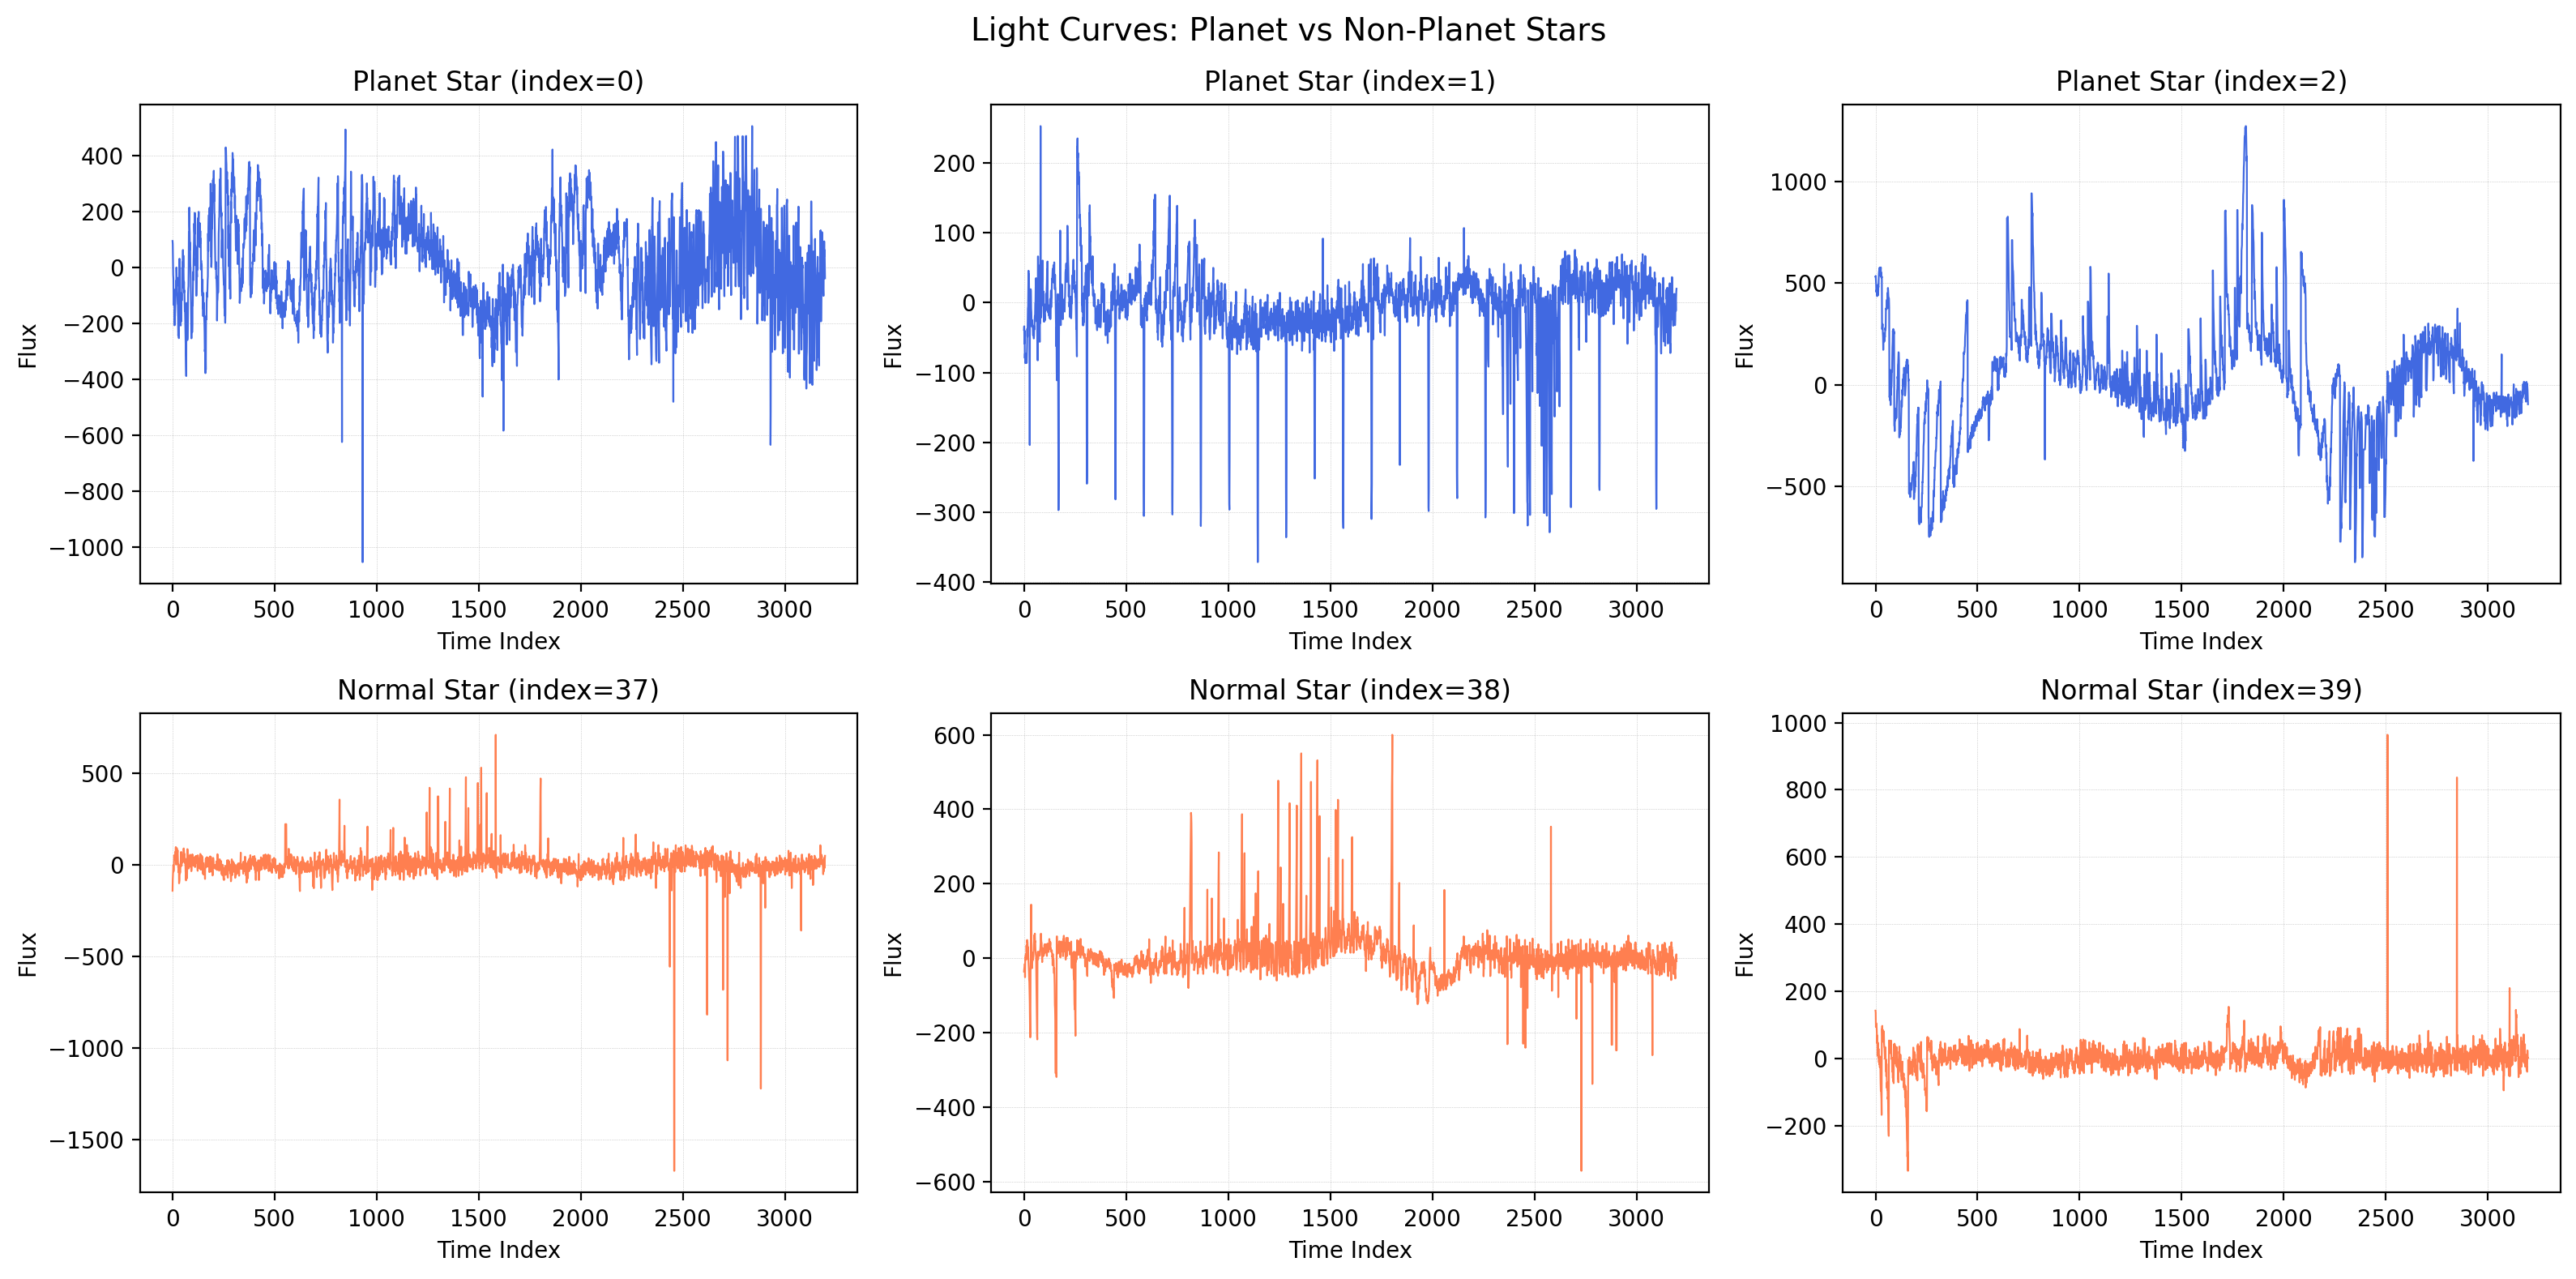

In [4]:
# ══════════════════════════════════════════════════════════════
# 2. EDA & LIGHT CURVE VISUALIZATION
# ══════════════════════════════════════════════════════════════
 
# ── 2.1 Light Curve Plots ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=200)
fig.suptitle('Light Curves: Planet vs Non-Planet Stars', fontsize=14)
 
planet_idx = exoTrain[exoTrain['LABEL'] == 2].index[:3]
normal_idx = exoTrain[exoTrain['LABEL'] == 1].index[:3]
 
for i, idx in enumerate(planet_idx):
    flux = exoTrain.iloc[idx].drop('LABEL')
    axes[0, i].plot(flux.values, color='royalblue', linewidth=0.8)
    axes[0, i].set_title(f'Planet Star (index={idx})')
    axes[0, i].set_xlabel('Time Index')
    axes[0, i].set_ylabel('Flux')
    axes[0, i].grid(axis='both', linestyle=':', linewidth=0.25)
 
for i, idx in enumerate(normal_idx):
    flux = exoTrain.iloc[idx].drop('LABEL')
    axes[1, i].plot(flux.values, color='coral', linewidth=0.8)
    axes[1, i].set_title(f'Normal Star (index={idx})')
    axes[1, i].set_xlabel('Time Index')
    axes[1, i].set_ylabel('Flux')
    axes[1, i].grid(axis='both', linestyle=':', linewidth=0.25)
 
plt.tight_layout()
plt.show()

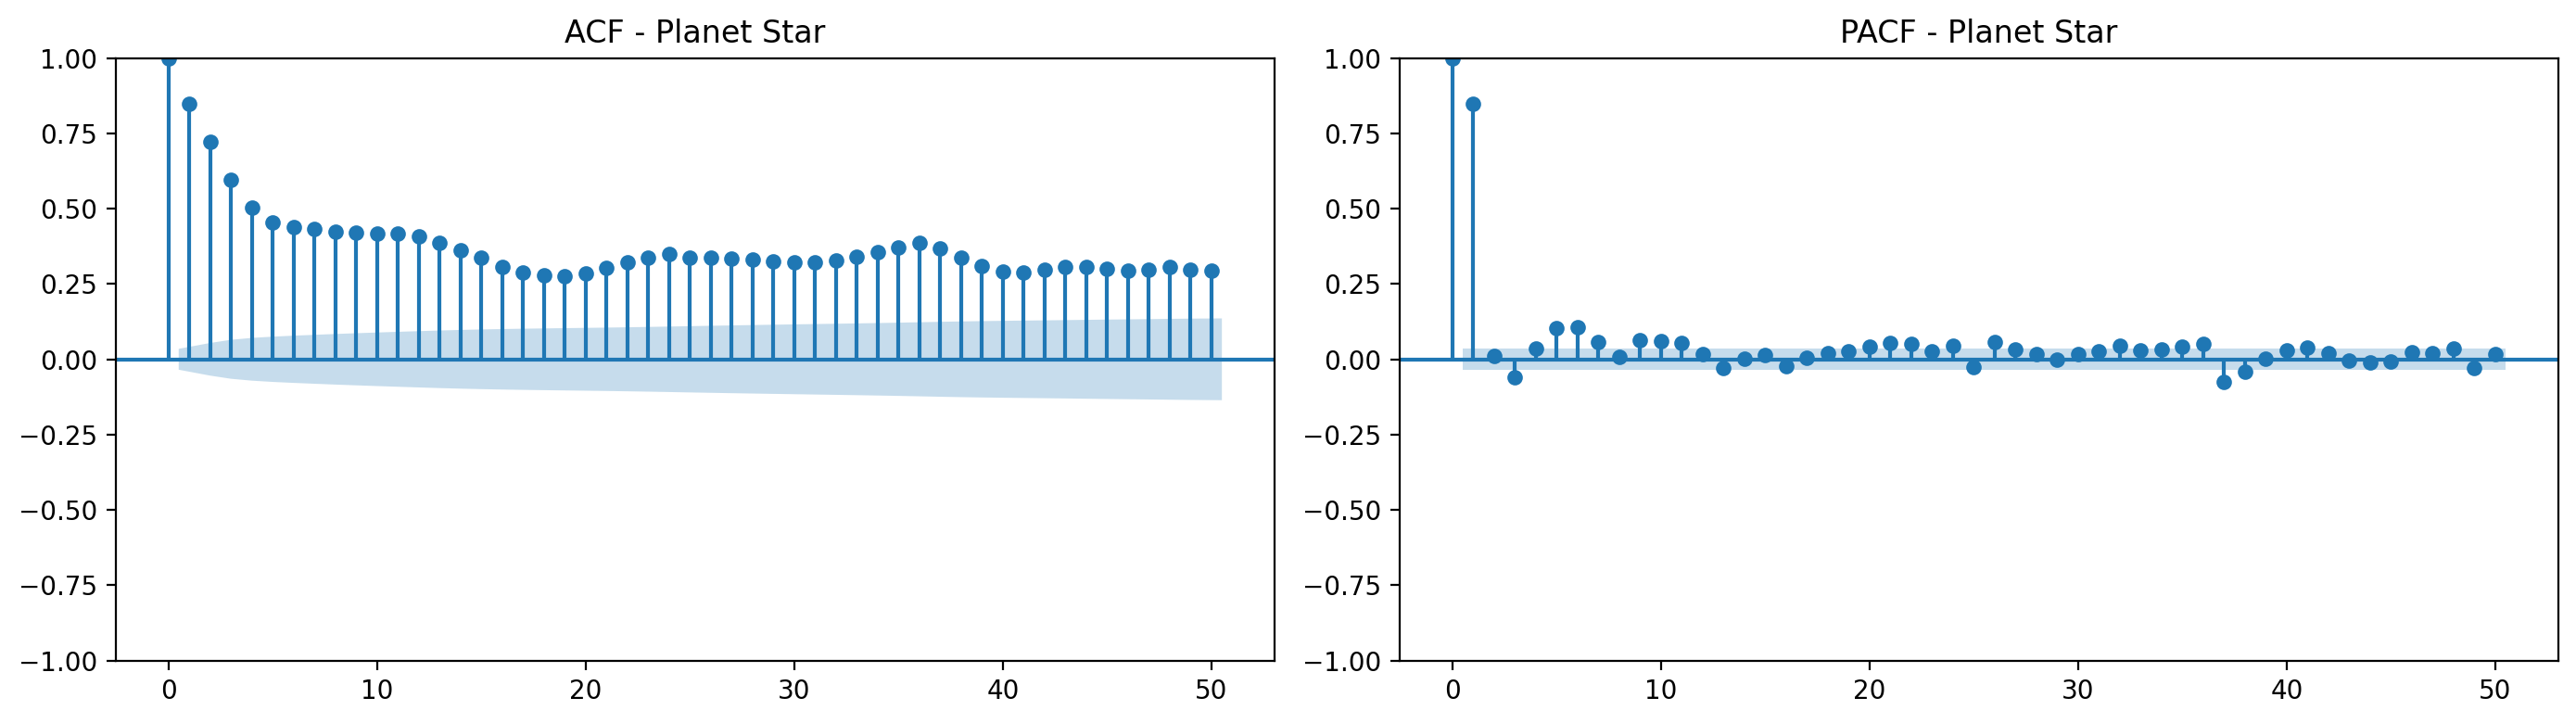

In [5]:
# ── 2.2 ACF / PACF for a Planet Star ────────────────────────
planet_flux = exoTrain[exoTrain['LABEL'] == 2].iloc[0].drop('LABEL').values
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=200)
plot_acf(planet_flux, lags=50, ax=axes[0])
axes[0].set_title('ACF - Planet Star')
plot_pacf(planet_flux, lags=50, ax=axes[1])
axes[1].set_title('PACF - Planet Star')
plt.tight_layout()
plt.show()

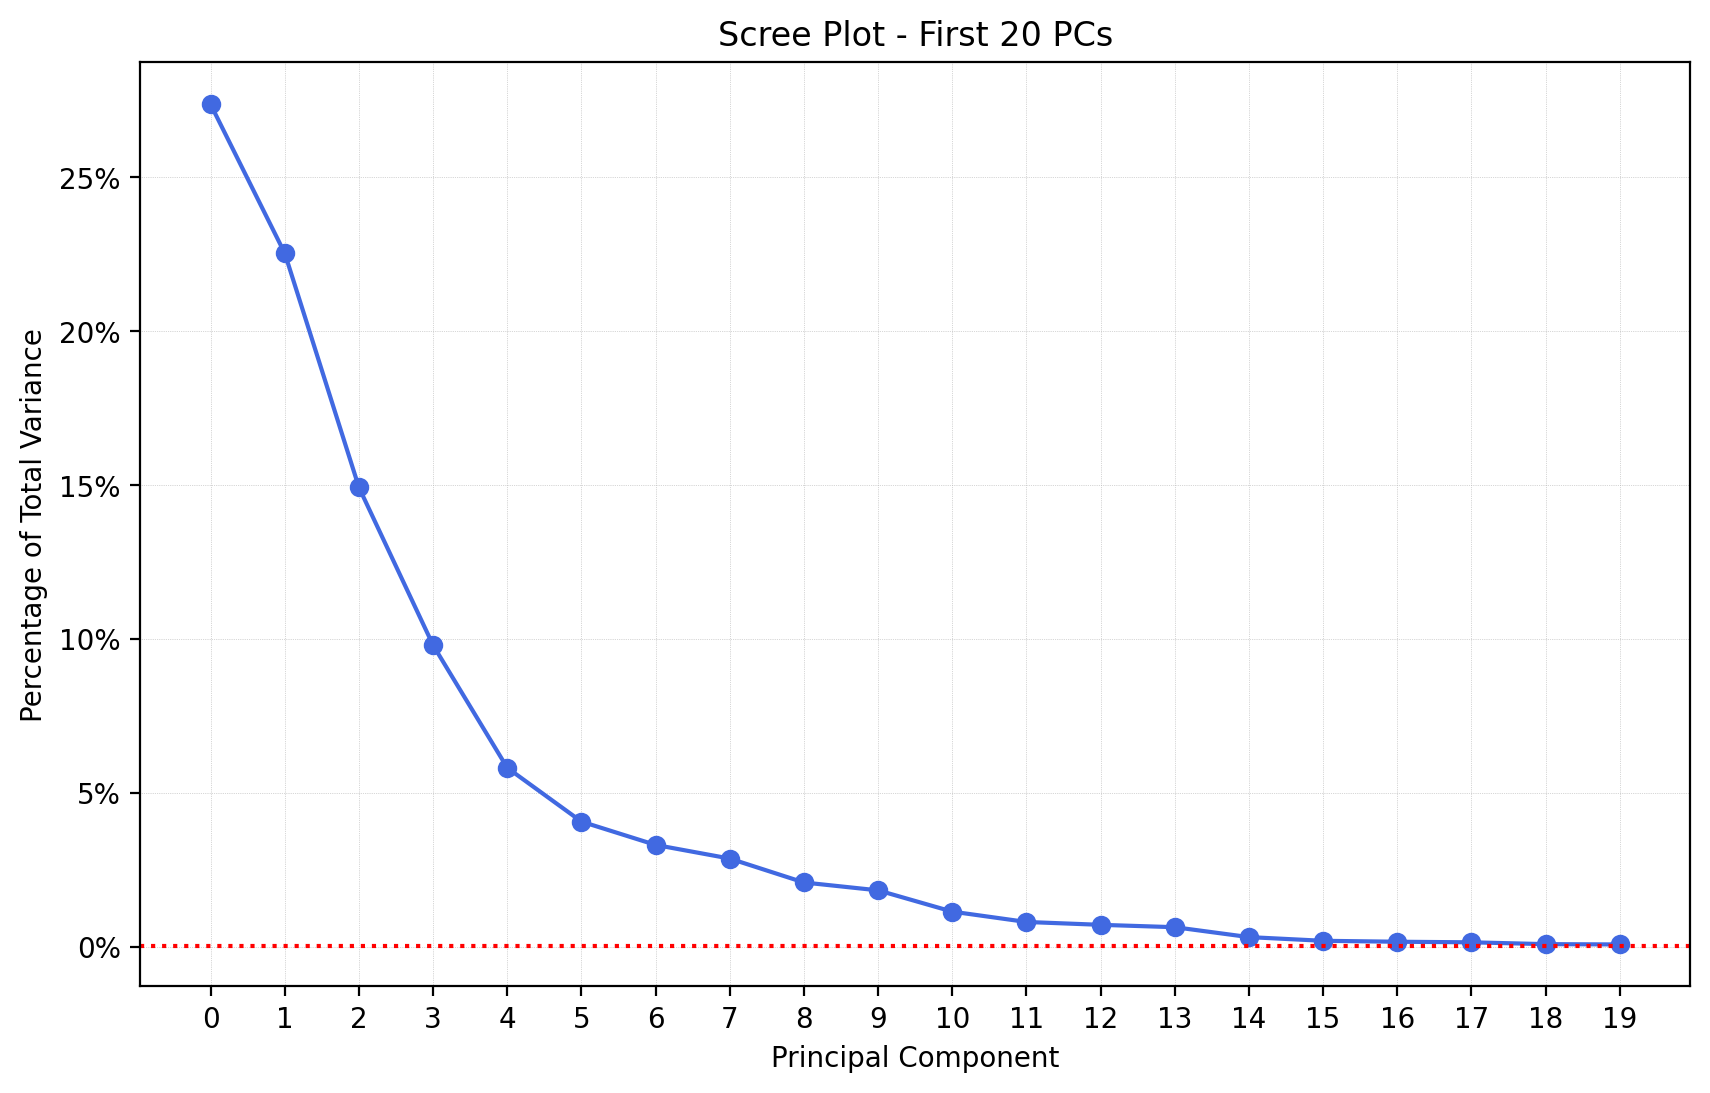

PC0: 27.37%  |  Cumulative: 27.37%
PC1: 22.54%  |  Cumulative: 49.91%
PC2: 14.93%  |  Cumulative: 64.84%
PC3: 9.80%  |  Cumulative: 74.64%
PC4: 5.82%  |  Cumulative: 80.46%
PC5: 4.07%  |  Cumulative: 84.53%
PC6: 3.32%  |  Cumulative: 87.85%
PC7: 2.87%  |  Cumulative: 90.72%
PC8: 2.10%  |  Cumulative: 92.82%
PC9: 1.84%  |  Cumulative: 94.66%
PC10: 1.15%  |  Cumulative: 95.81%


In [6]:
# ── 2.3 PCA Scree Plot (EDA only) ────────────────────────────
train_X_eda = exoTrain.drop(columns=['LABEL'])
scaler_eda  = StandardScaler()
train_X_scaled_eda = pd.DataFrame(
    scaler_eda.fit_transform(train_X_eda),
    columns=train_X_eda.columns
)
 
num_vars   = train_X_scaled_eda.shape[1]
cov_matrix = train_X_scaled_eda.cov(ddof=1)
evalues, evectors = np.linalg.eig(cov_matrix)
 
sign_e0 = np.sign(evectors[0, :])
for i in range(num_vars):
    evectors[i, :] = evectors[i, :] * sign_e0
 
pct_evalues = 100.0 * (evalues / evalues.sum())
cumulative  = np.cumsum(pct_evalues)
 
fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=200)
ax.plot(range(20), pct_evalues[:20], color='royalblue', marker='o')
ax.axhline(100.0 / num_vars, color='red', linestyle=':')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Percentage of Total Variance')
ax.set_xticks(range(20))
ax.yaxis.set_major_locator(MultipleLocator(base=5.0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100.0, decimals=0))
ax.grid(axis='both', linestyle=':', linewidth=0.25)
plt.title('Scree Plot - First 20 PCs')
plt.show()
 
for i in range(11):
    print(f'PC{i}: {pct_evalues[i]:.2f}%  |  Cumulative: {cumulative[i]:.2f}%')

In [8]:
# ══════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING (for Tabular ML)
# ══════════════════════════════════════════════════════════════
 
train_X_raw = exoTrain.drop(columns=['LABEL']).values
train_y     = exoTrain['LABEL']
test_X_raw  = exoTest.drop(columns=['LABEL']).values
test_y      = exoTest['LABEL']

In [9]:
# ── 3.1 FFT ──────────────────────────────────────────────────
def apply_fft(data):
    fft_data = np.abs(fft(data, axis=1))
    fft_data = fft_data[:, :fft_data.shape[1] // 2]
    mean = fft_data.mean(axis=1, keepdims=True)
    std  = fft_data.std(axis=1, keepdims=True)
    std[std == 0] = 1
    return (fft_data - mean) / std

In [10]:
# ── 3.2 Summary Stats ─────────────────────────────────────────
def extract_summary_stats(data):
    data = np.array(data)
    return np.column_stack([
        np.mean(data, axis=1),
        np.median(data, axis=1),
        np.std(data, axis=1),
        np.min(data, axis=1),
        np.max(data, axis=1),
        np.max(data, axis=1) - np.min(data, axis=1),
        np.percentile(data, 25, axis=1),
        np.percentile(data, 75, axis=1),
        np.percentile(data, 75, axis=1) - np.percentile(data, 25, axis=1),
        skew(data, axis=1),
        kurtosis(data, axis=1),
        np.mean(np.abs(np.diff(data, axis=1)), axis=1),
        np.std(np.diff(data, axis=1), axis=1),
        np.sum(np.abs(data) > 2 * np.std(data, axis=1, keepdims=True), axis=1),
        np.sum(np.diff(
            np.sign(data - np.mean(data, axis=1, keepdims=True)), axis=1
        ) != 0, axis=1),
    ])

In [11]:
# ── 3.3 Dip Detection ─────────────────────────────────────────
def dip_detection_features(data, std_threshold=2.0):
    data = np.array(data)
    features = []
    for row in data:
        mean = np.mean(row)
        std  = np.std(row)
        inverted = -row
        peaks, properties = find_peaks(
            inverted, height=-mean, distance=20, prominence=std * 0.5
        )
        threshold   = mean - std_threshold * std
        deep_dips   = row[row < threshold]
        below       = (row < threshold).astype(int)
        dip_lengths = []
        count = 0
        for val in below:
            if val == 1:
                count += 1
            elif count > 0:
                dip_lengths.append(count)
                count = 0
        if count > 0:
            dip_lengths.append(count)
 
        row_feats = [
            len(peaks),
            np.max(properties['prominences']) if len(peaks) > 0 else 0,
            np.mean(properties['prominences']) if len(peaks) > 0 else 0,
            (mean - np.min(row)) / (std + 1e-10),
            len(deep_dips),
            len(deep_dips) / len(row),
            np.max(dip_lengths) if dip_lengths else 0,
            np.mean(dip_lengths) if dip_lengths else 0,
            len(dip_lengths),
        ]
        if len(peaks) >= 2:
            spacings = np.diff(peaks)
            row_feats.extend([np.mean(spacings), np.std(spacings), np.min(spacings)])
        else:
            row_feats.extend([0, 0, 0])
        features.append(row_feats)
    return np.array(features)

In [12]:
# ── 3.4 Autocorrelation ───────────────────────────────────────
def autocorrelation_features(data, lags=[10, 25, 50, 100, 200, 500]):
    data = np.array(data)
    features = []
    for row in data:
        row  = row - np.mean(row)
        norm = np.sum(row ** 2)
        row_feats = []
        for lag in lags:
            if lag < len(row):
                ac = np.sum(row[:len(row)-lag] * row[lag:]) / (norm + 1e-10)
                row_feats.append(ac)
            else:
                row_feats.append(0)
        all_ac = []
        for lag in range(1, min(500, len(row))):
            ac = np.sum(row[:len(row)-lag] * row[lag:]) / (norm + 1e-10)
            all_ac.append(ac)
        all_ac = np.array(all_ac)
        peaks, _ = find_peaks(all_ac, distance=5)
        if len(peaks) > 0:
            best_peak = peaks[np.argmax(all_ac[peaks])]
            row_feats.extend([best_peak, all_ac[best_peak]])
        else:
            row_feats.extend([0, 0])
        features.append(row_feats)
    return np.array(features)

In [13]:
# ── 3.5 Rolling Window ────────────────────────────────────────
def rolling_window_features(data, windows=[50, 100, 200]):
    data = np.array(data)
    features = []
    for row in data:
        row_feats = []
        for w in windows:
            n = len(row)
            w = min(w, n)
            shape   = (n - w + 1, w)
            strides = (row.strides[0], row.strides[0])
            wv = np.lib.stride_tricks.as_strided(row, shape=shape, strides=strides)
            roll_mean = np.mean(wv, axis=1)
            roll_std  = np.std(wv, axis=1)
            roll_min  = np.min(wv, axis=1)
            row_feats.extend([
                np.min(roll_mean), np.std(roll_mean),
                np.max(roll_std),
                np.min(roll_min), np.mean(roll_min),
                np.argmin(roll_mean) / len(roll_mean),
            ])
        features.append(row_feats)
    return np.array(features)

In [14]:
# ── 3.6 Derivative ────────────────────────────────────────────
def derivative_features(data):
    data = np.array(data)
    features = []
    for row in data:
        d1 = np.diff(row)
        d2 = np.diff(d1)
        features.append([
            np.mean(np.abs(d1)), np.max(np.abs(d1)), np.std(d1),
            np.min(d1), np.max(d1),
            np.mean(np.abs(d2)), np.max(np.abs(d2)), np.std(d2),
        ])
    return np.array(features)

In [15]:
# ── 3.7 Extract & Combine ─────────────────────────────────────
print('Extracting FFT...')
X_tr_fft   = apply_fft(train_X_raw);   X_te_fft   = apply_fft(test_X_raw)
 
print('Extracting Summary Stats...')
X_tr_stats = extract_summary_stats(train_X_raw)
X_te_stats = extract_summary_stats(test_X_raw)
 
print('Extracting Dip Detection...')
X_tr_dips  = dip_detection_features(train_X_raw)
X_te_dips  = dip_detection_features(test_X_raw)
 
print('Extracting Autocorrelation...')
X_tr_ac    = autocorrelation_features(train_X_raw)
X_te_ac    = autocorrelation_features(test_X_raw)
 
print('Extracting Rolling Window...')
X_tr_roll  = rolling_window_features(train_X_raw)
X_te_roll  = rolling_window_features(test_X_raw)
 
print('Extracting Derivatives...')
X_tr_deriv = derivative_features(train_X_raw)
X_te_deriv = derivative_features(test_X_raw)
 
train_X = pd.DataFrame(np.hstack([
    X_tr_fft, X_tr_stats, X_tr_dips, X_tr_ac, X_tr_roll, X_tr_deriv
]))
test_X = pd.DataFrame(np.hstack([
    X_te_fft, X_te_stats, X_te_dips, X_te_ac, X_te_roll, X_te_deriv
]))
 
print(f'\nFeature breakdown:')
print(f'  FFT:             {X_tr_fft.shape[1]}')
print(f'  Summary Stats:   {X_tr_stats.shape[1]}')
print(f'  Dip Detection:   {X_tr_dips.shape[1]}')
print(f'  Autocorrelation: {X_tr_ac.shape[1]}')
print(f'  Rolling Window:  {X_tr_roll.shape[1]}')
print(f'  Derivatives:     {X_tr_deriv.shape[1]}')
print(f'  TOTAL:           {train_X.shape[1]}')

Extracting FFT...
Extracting Summary Stats...
Extracting Dip Detection...
Extracting Autocorrelation...
Extracting Rolling Window...
Extracting Derivatives...

Feature breakdown:
  FFT:             1598
  Summary Stats:   15
  Dip Detection:   12
  Autocorrelation: 8
  Rolling Window:  18
  Derivatives:     8
  TOTAL:           1659


In [16]:
# ══════════════════════════════════════════════════════════════
# 4. TABULAR ML HELPERS
# ══════════════════════════════════════════════════════════════
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
def evaluate_model(model, test_X, test_y, oof_proba, planet_col,
                   title='Model', is_xgb=False):
    """Shared evaluation: threshold tuning + confusion matrix + ROC curve."""
 
    # OOF threshold tuning
    oof_prob = oof_proba[:, planet_col]
    if is_xgb:
        train_true = (train_y - 1 == 1).astype(int).values
    else:
        train_true = (train_y == 2).astype(int).values
 
    prec, rec, thr = precision_recall_curve(train_true, oof_prob)
    f1      = 2 * prec[1:] * rec[1:] / (prec[1:] + rec[1:] + 1e-12)
    best_idx = np.argmax(f1)
    best_thr = thr[best_idx]
 
    print(f'\nBest Threshold (OOF): {best_thr:.4f}')
    print(f'OOF Precision: {prec[1:][best_idx]:.4f}')
    print(f'OOF Recall:    {rec[1:][best_idx]:.4f}')
    print(f'OOF F1:        {f1[best_idx]:.4f}')
 
    # Predictions
    test_prob = model.predict_proba(test_X)[:, planet_col]
 
    if is_xgb:
        y_true_bin    = (test_y - 1 == 1).astype(int)
        pred_default  = model.predict(test_X)
        pred_tuned    = np.where(test_prob >= best_thr, 1, 0)
        pred_default_label = pred_default + 1
        pred_tuned_label   = pred_tuned + 1
    else:
        y_true_bin   = (test_y == 2).astype(int)
        pred_default = model.predict(test_X)
        pred_tuned   = np.where(test_prob >= best_thr, 2, 1)
        pred_default_label = pred_default
        pred_tuned_label   = pred_tuned
 
    print(f'\n=== Confusion Matrix (Default Threshold = 0.5) ===')
    print(confusion_matrix(test_y, pred_default_label, labels=[2, 1]))
    print(classification_report(test_y, pred_default_label,
          labels=[2, 1], target_names=['Planet (2)', 'Non-planet (1)']))
 
    print(f'\n=== Confusion Matrix (Tuned Threshold) ===')
    print(confusion_matrix(test_y, pred_tuned_label, labels=[2, 1]))
    print(classification_report(test_y, pred_tuned_label,
          labels=[2, 1], target_names=['Planet (2)', 'Non-planet (1)']))
 
    auc = roc_auc_score(y_true_bin, test_prob)
    ap  = average_precision_score(y_true_bin, test_prob)
    print(f'ROC-AUC: {auc:.4f}')
    print(f'PR-AUC:  {ap:.4f}')
 
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true_bin, test_prob)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=200)
    ax.plot(fpr, tpr, color='royalblue', label=f'ROC-AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], color='red', linestyle=':', label='Random Guess')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {title}')
    ax.legend()
    ax.grid(axis='both', linestyle=':', linewidth=0.25)
    plt.show()
 
    return auc, ap


LOGISTIC REGRESSION
AUC per fold: [0.9849 0.8916 0.9559 0.9849 0.9557]
Mean AUC:     0.9546  |  Std: 0.0341

Best Threshold (OOF): 0.7369
OOF Precision: 0.6667
OOF Recall:    0.4865
OOF F1:        0.5625

=== Confusion Matrix (Default Threshold = 0.5) ===
[[  3   2]
 [  2 563]]
                precision    recall  f1-score   support

    Planet (2)       0.60      0.60      0.60         5
Non-planet (1)       1.00      1.00      1.00       565

      accuracy                           0.99       570
     macro avg       0.80      0.80      0.80       570
  weighted avg       0.99      0.99      0.99       570


=== Confusion Matrix (Tuned Threshold) ===
[[  3   2]
 [  2 563]]
                precision    recall  f1-score   support

    Planet (2)       0.60      0.60      0.60         5
Non-planet (1)       1.00      1.00      1.00       565

      accuracy                           0.99       570
     macro avg       0.80      0.80      0.80       570
  weighted avg       0.99      0

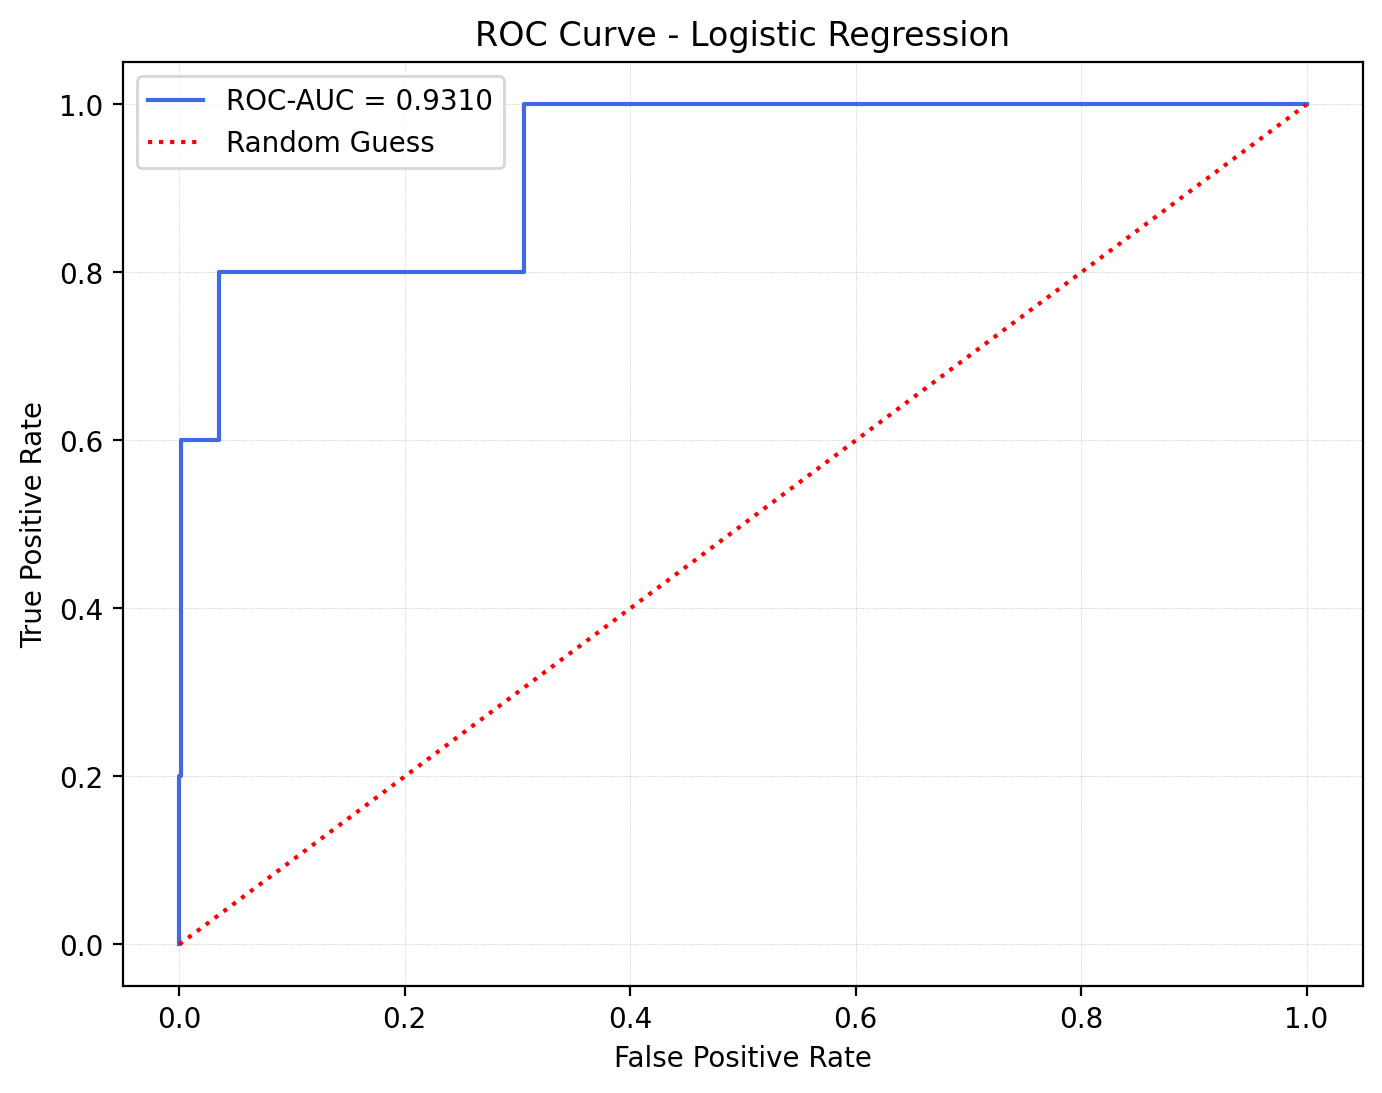

In [17]:
# ══════════════════════════════════════════════════════════════
# 5. LOGISTIC REGRESSION
# ══════════════════════════════════════════════════════════════
 
def auc_planet_lr(estimator, X, y):
    proba      = estimator.predict_proba(X)
    planet_col = list(estimator.named_steps['lr'].classes_).index(2)
    y_true     = (y == 2).astype(int)
    return roc_auc_score(y_true, proba[:, planet_col])
 
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, class_weight='balanced'))
])
 
print('\n' + '='*60)
print('LOGISTIC REGRESSION')
print('='*60)
 
cv_auc = cross_val_score(pipe_lr, train_X, train_y, cv=cv, scoring=auc_planet_lr)
print(f'AUC per fold: {cv_auc.round(4)}')
print(f'Mean AUC:     {cv_auc.mean():.4f}  |  Std: {cv_auc.std():.4f}')
 
pipe_lr.fit(train_X, train_y)
planet_col_lr = list(pipe_lr.named_steps['lr'].classes_).index(2)
 
oof_proba_lr = cross_val_predict(
    pipe_lr, train_X, train_y, cv=cv, method='predict_proba'
)
 
lr_auc, lr_ap = evaluate_model(
    pipe_lr, test_X, test_y, oof_proba_lr,
    planet_col_lr, title='Logistic Regression'
)


RANDOM FOREST


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 363}
Best CV AUC: 0.9456
AUC per fold: [0.9457 0.8184 0.987  0.9982 0.9788]
Mean AUC:     0.9456  |  Std: 0.0660


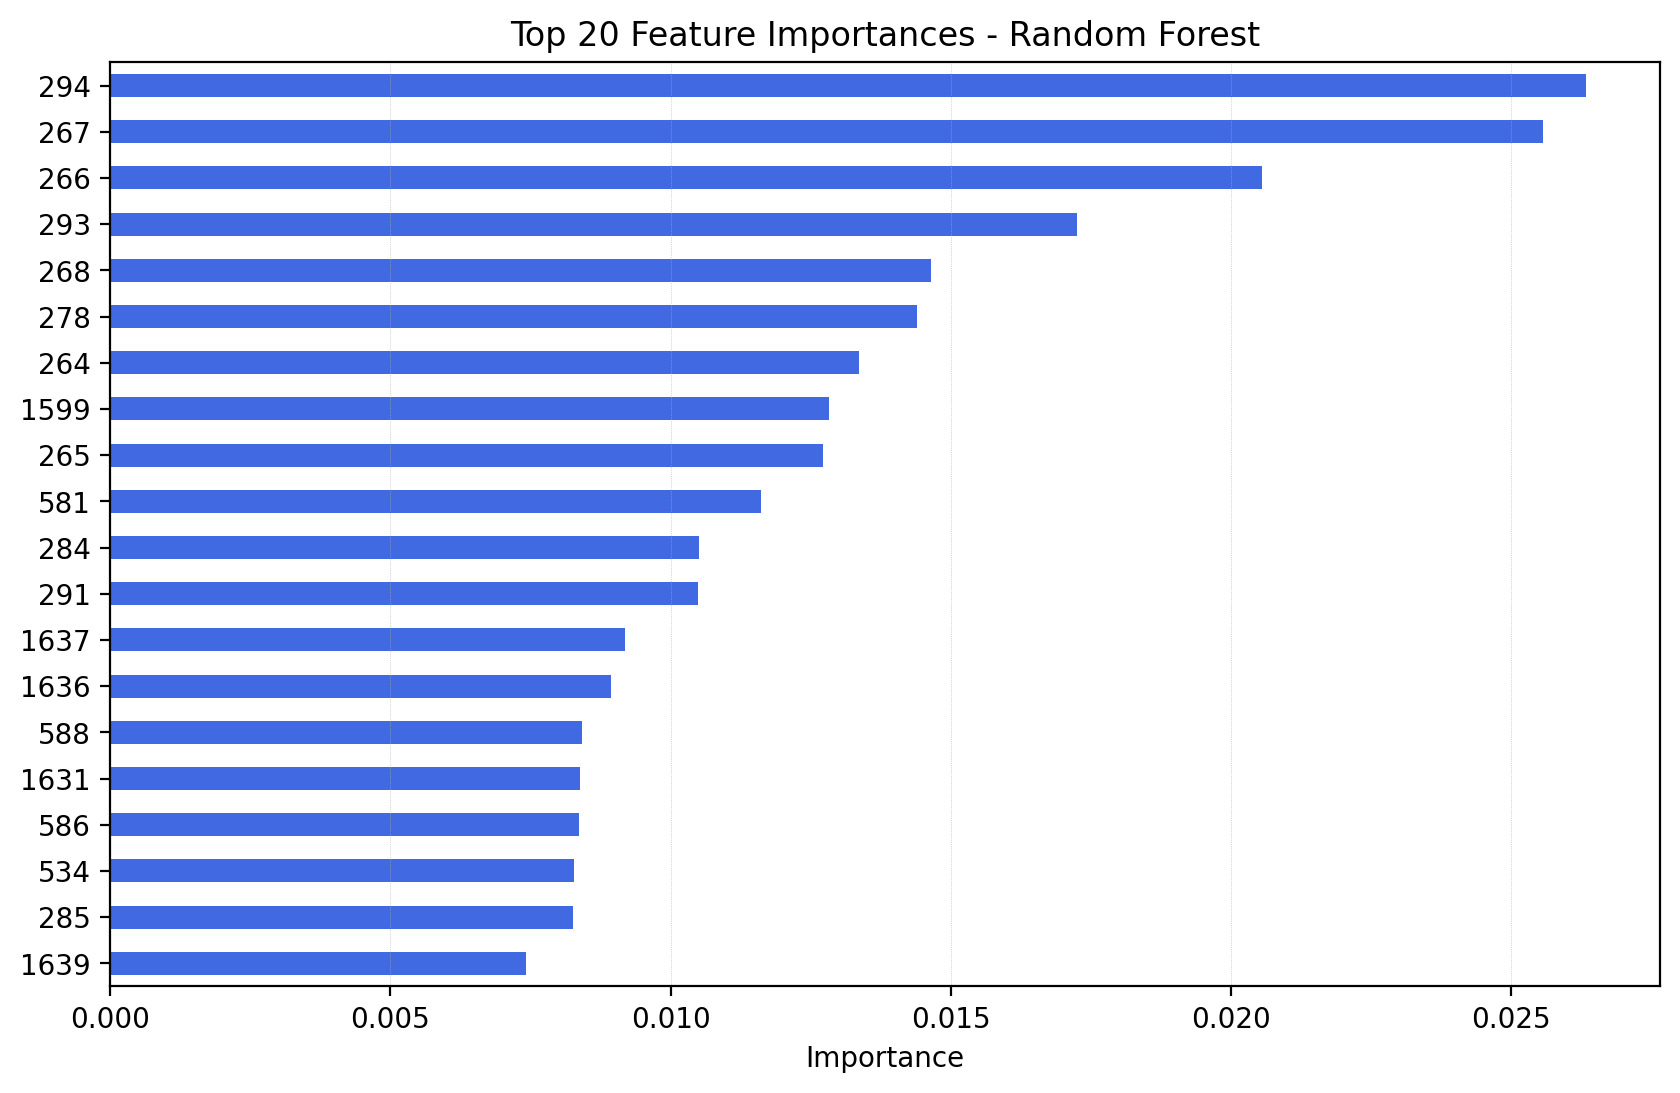


Best Threshold (OOF): 0.1231
OOF Precision: 0.7222
OOF Recall:    0.3514
OOF F1:        0.4727

=== Confusion Matrix (Default Threshold = 0.5) ===
[[  0   5]
 [  0 565]]
                precision    recall  f1-score   support

    Planet (2)       0.00      0.00      0.00         5
Non-planet (1)       0.99      1.00      1.00       565

      accuracy                           0.99       570
     macro avg       0.50      0.50      0.50       570
  weighted avg       0.98      0.99      0.99       570


=== Confusion Matrix (Tuned Threshold) ===
[[  2   3]
 [  2 563]]
                precision    recall  f1-score   support

    Planet (2)       0.50      0.40      0.44         5
Non-planet (1)       0.99      1.00      1.00       565

      accuracy                           0.99       570
     macro avg       0.75      0.70      0.72       570
  weighted avg       0.99      0.99      0.99       570

ROC-AUC: 0.9950
PR-AUC:  0.6222


/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jj/PycharmProjects/ML assignment 1 /.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


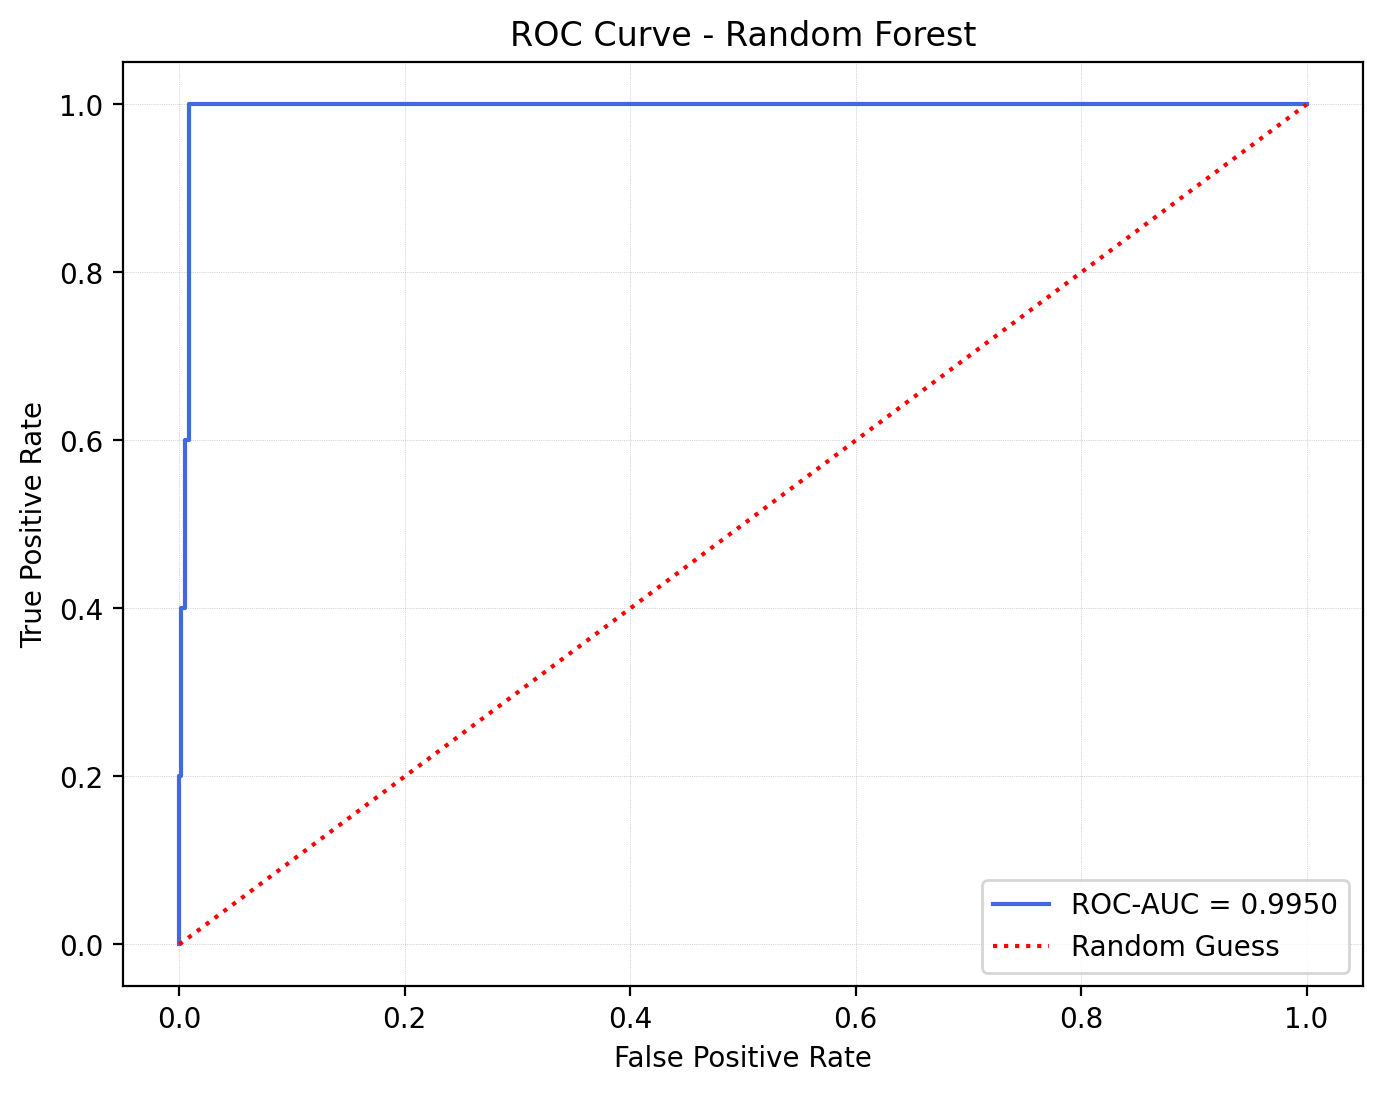

In [19]:
# ══════════════════════════════════════════════════════════════
# 6. RANDOM FOREST
# ══════════════════════════════════════════════════════════════
 
def auc_planet_rf(estimator, X, y):
    proba      = estimator.predict_proba(X)
    planet_col = list(estimator.classes_).index(2)
    y_true     = (y == 2).astype(int)
    return roc_auc_score(y_true, proba[:, planet_col])
 
print('\n' + '='*60)
print('RANDOM FOREST')
print('='*60)
 
# ── Hyperparameter Tuning via Random Search ───────────────────
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
 
param_dist_rf = {
    'n_estimators':     randint(100, 600),
    'max_depth':        [None, 10, 15, 20, 30],
    'min_samples_leaf': randint(1, 5),
    'max_features':     ['sqrt', 'log2'],
}
 
rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1
)
 
rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=cv,
    scoring=auc_planet_rf,
    random_state=42,
    n_jobs=-1
)
 
rf_search.fit(train_X, train_y)
print(f'Best params: {rf_search.best_params_}')
print(f'Best CV AUC: {rf_search.best_score_:.4f}')
 
rf = rf_search.best_estimator_
 
# ── CV AUC with best estimator ────────────────────────────────
cv_auc = cross_val_score(rf, train_X, train_y, cv=cv, scoring=auc_planet_rf)
print(f'AUC per fold: {cv_auc.round(4)}')
print(f'Mean AUC:     {cv_auc.mean():.4f}  |  Std: {cv_auc.std():.4f}')
 
rf.fit(train_X, train_y)
planet_col_rf = list(rf.classes_).index(2)
 
# Feature Importance
importances = pd.Series(rf.feature_importances_)
top20 = importances.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=200)
top20.sort_values().plot(kind='barh', ax=ax, color='royalblue')
ax.set_title('Top 20 Feature Importances - Random Forest')
ax.set_xlabel('Importance')
ax.grid(axis='x', linestyle=':', linewidth=0.25)
plt.show()
 
oof_proba_rf = cross_val_predict(
    rf, train_X, train_y, cv=cv, method='predict_proba'
)
 
rf_auc, rf_ap = evaluate_model(
    rf, test_X, test_y, oof_proba_rf,
    planet_col_rf, title='Random Forest'
)


XGBOOST
Best params: {'colsample_bytree': np.float64(0.8417669517111269), 'learning_rate': np.float64(0.11796821826033463), 'max_depth': 7, 'n_estimators': 135, 'subsample': np.float64(0.9771414282231924)}
Best CV AUC: 0.9899
AUC per fold: [0.9542 0.9957 1.     1.     0.9997]
Mean AUC:     0.9899  |  Std: 0.0179


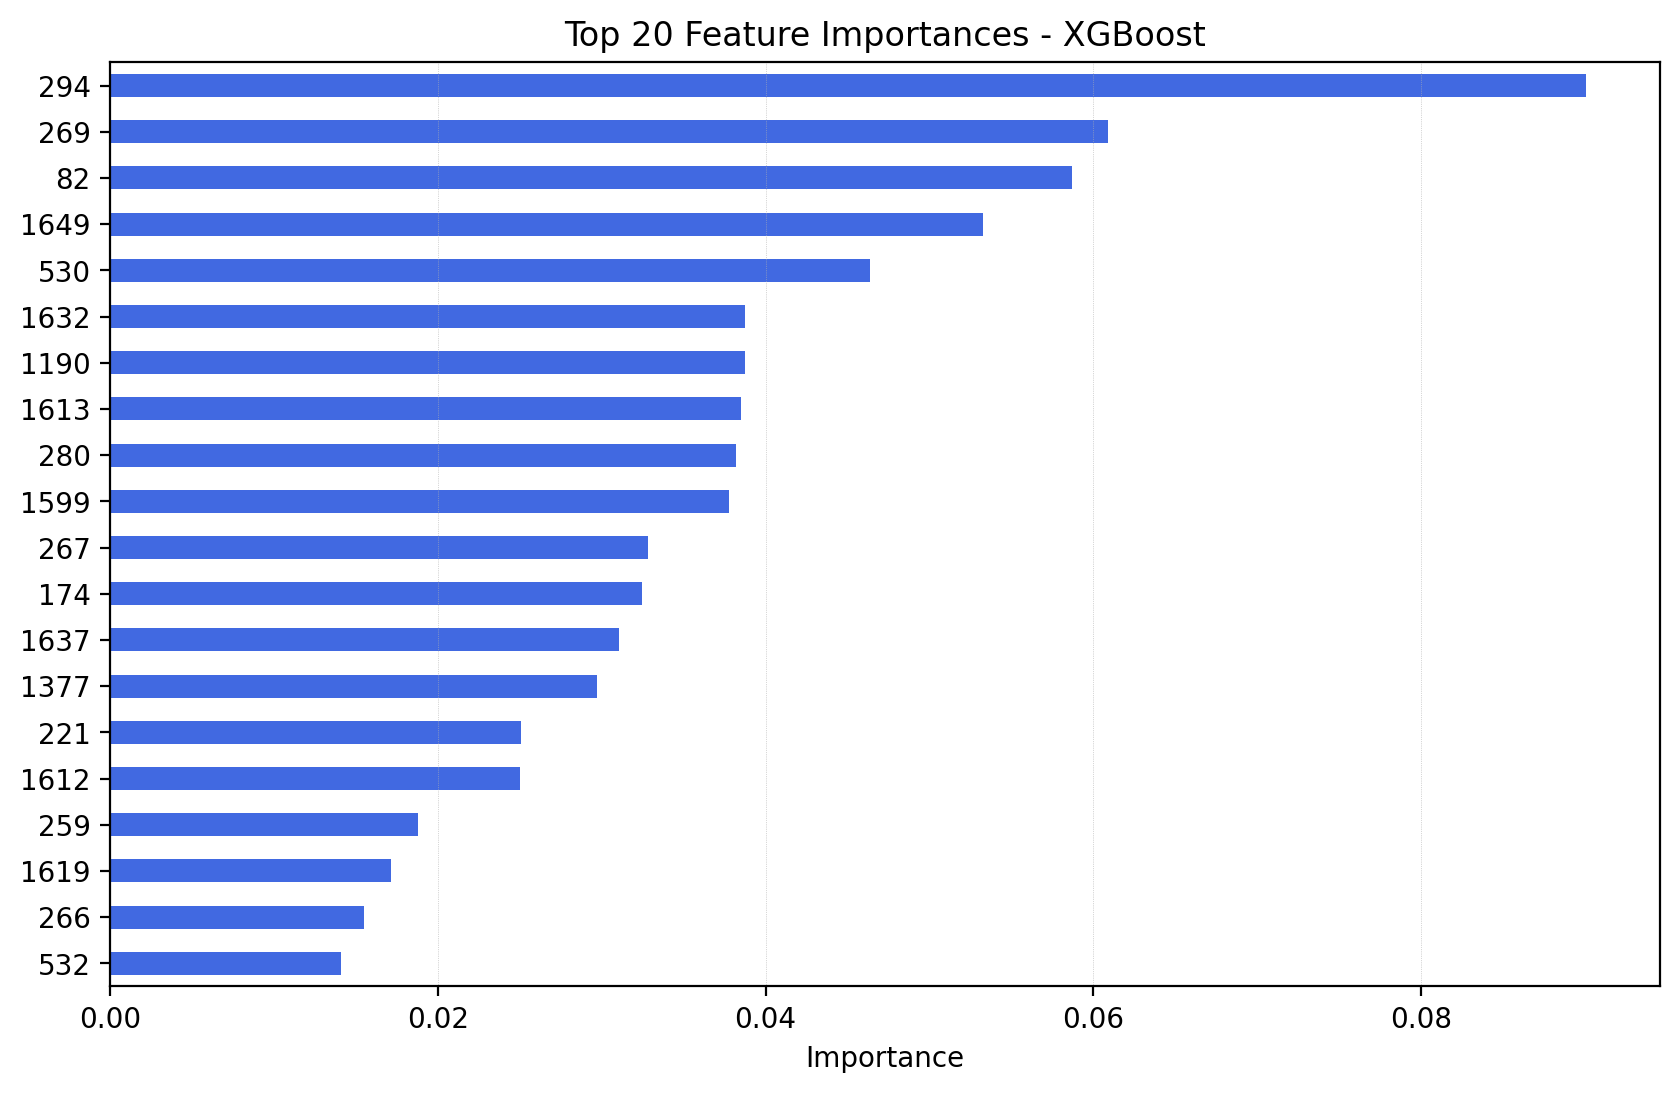


Best Threshold (OOF): 0.0291
OOF Precision: 0.9143
OOF Recall:    0.8649
OOF F1:        0.8889

=== Confusion Matrix (Default Threshold = 0.5) ===
[[  3   2]
 [  0 565]]
                precision    recall  f1-score   support

    Planet (2)       1.00      0.60      0.75         5
Non-planet (1)       1.00      1.00      1.00       565

      accuracy                           1.00       570
     macro avg       1.00      0.80      0.87       570
  weighted avg       1.00      1.00      1.00       570


=== Confusion Matrix (Tuned Threshold) ===
[[  4   1]
 [  0 565]]
                precision    recall  f1-score   support

    Planet (2)       1.00      0.80      0.89         5
Non-planet (1)       1.00      1.00      1.00       565

      accuracy                           1.00       570
     macro avg       1.00      0.90      0.94       570
  weighted avg       1.00      1.00      1.00       570

ROC-AUC: 0.9958
PR-AUC:  0.8588


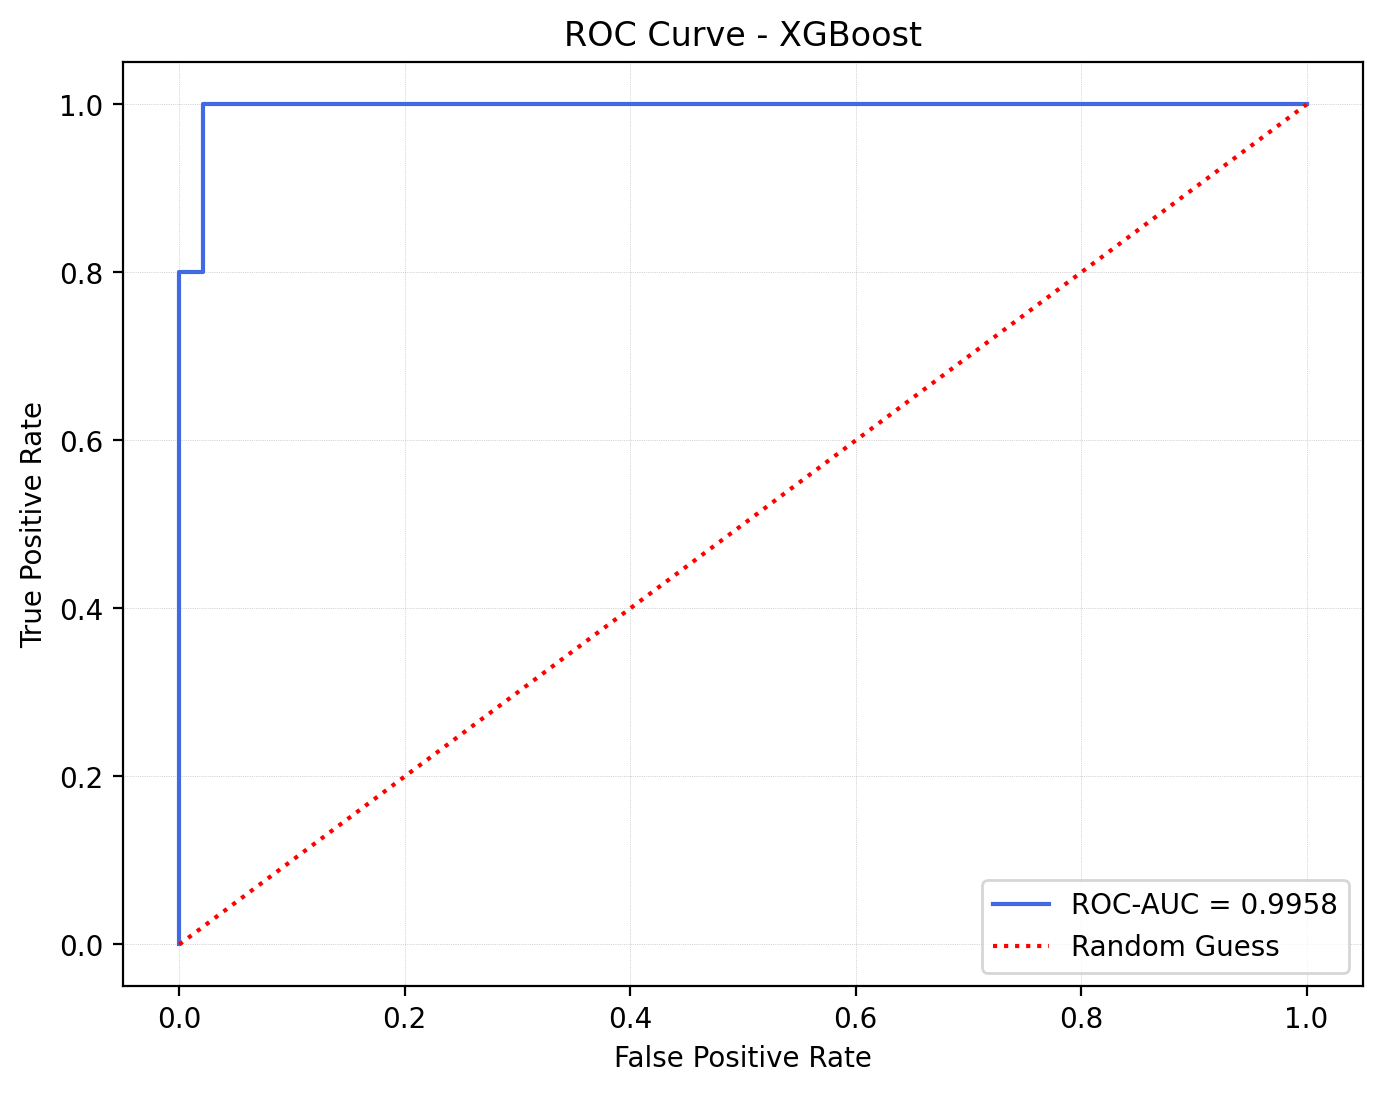

In [20]:
# ══════════════════════════════════════════════════════════════
# 7. XGBOOST
# ══════════════════════════════════════════════════════════════
 
train_y_xgb = train_y - 1
test_y_xgb  = test_y - 1
 
def auc_planet_xgb(estimator, X, y):
    proba  = estimator.predict_proba(X)
    y_true = (y == 1).astype(int)
    return roc_auc_score(y_true, proba[:, 1])
 
scale_pos_weight = (train_y_xgb == 0).sum() / (train_y_xgb == 1).sum()
 
print('\n' + '='*60)
print('XGBOOST')
print('='*60)
 
# ── Hyperparameter Tuning via Random Search ───────────────────
from scipy.stats import uniform
 
param_dist_xgb = {
    'n_estimators':    randint(100, 500),
    'max_depth':       randint(3, 8),
    'learning_rate':   uniform(0.01, 0.2),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}
 
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1,
    eval_metric='logloss', verbosity=0
)
 
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=cv,
    scoring=auc_planet_xgb,
    random_state=42,
    n_jobs=-1
)
 
xgb_search.fit(train_X, train_y_xgb)
print(f'Best params: {xgb_search.best_params_}')
print(f'Best CV AUC: {xgb_search.best_score_:.4f}')
 
xgb = xgb_search.best_estimator_
 
# ── CV AUC with best estimator ────────────────────────────────
cv_auc = cross_val_score(
    xgb, train_X, train_y_xgb, cv=cv, scoring=auc_planet_xgb
)
print(f'AUC per fold: {cv_auc.round(4)}')
print(f'Mean AUC:     {cv_auc.mean():.4f}  |  Std: {cv_auc.std():.4f}')
 
xgb.fit(train_X, train_y_xgb)
 
# Feature Importance
importances_xgb = pd.Series(xgb.feature_importances_)
top20_xgb = importances_xgb.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=200)
top20_xgb.sort_values().plot(kind='barh', ax=ax, color='royalblue')
ax.set_title('Top 20 Feature Importances - XGBoost')
ax.set_xlabel('Importance')
ax.grid(axis='x', linestyle=':', linewidth=0.25)
plt.show()
 
oof_proba_xgb = cross_val_predict(
    xgb, train_X, train_y_xgb, cv=cv, method='predict_proba', n_jobs=-1
)
 
# XGBoost uses 0/1 labels — handle separately
oof_prob_xgb  = oof_proba_xgb[:, 1]
train_true_xgb = (train_y_xgb == 1).astype(int).values
 
prec, rec, thr = precision_recall_curve(train_true_xgb, oof_prob_xgb)
f1       = 2 * prec[1:] * rec[1:] / (prec[1:] + rec[1:] + 1e-12)
best_idx = np.argmax(f1)
best_thr_xgb = thr[best_idx]
 
print(f'\nBest Threshold (OOF): {best_thr_xgb:.4f}')
print(f'OOF Precision: {prec[1:][best_idx]:.4f}')
print(f'OOF Recall:    {rec[1:][best_idx]:.4f}')
print(f'OOF F1:        {f1[best_idx]:.4f}')
 
test_prob_xgb   = xgb.predict_proba(test_X)[:, 1]
y_true_xgb      = (test_y_xgb == 1).astype(int)
pred_default_xgb = xgb.predict(test_X)
pred_tuned_xgb   = np.where(test_prob_xgb >= best_thr_xgb, 1, 0)
 
print('\n=== Confusion Matrix (Default Threshold = 0.5) ===')
print(confusion_matrix(test_y, pred_default_xgb + 1, labels=[2, 1]))
print(classification_report(test_y, pred_default_xgb + 1,
      labels=[2, 1], target_names=['Planet (2)', 'Non-planet (1)']))
 
print('\n=== Confusion Matrix (Tuned Threshold) ===')
print(confusion_matrix(test_y, pred_tuned_xgb + 1, labels=[2, 1]))
print(classification_report(test_y, pred_tuned_xgb + 1,
      labels=[2, 1], target_names=['Planet (2)', 'Non-planet (1)']))
 
xgb_auc = roc_auc_score(y_true_xgb, test_prob_xgb)
xgb_ap  = average_precision_score(y_true_xgb, test_prob_xgb)
print(f'ROC-AUC: {xgb_auc:.4f}')
print(f'PR-AUC:  {xgb_ap:.4f}')
 
fpr, tpr, _ = roc_curve(y_true_xgb, test_prob_xgb)
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=200)
ax.plot(fpr, tpr, color='royalblue', label=f'ROC-AUC = {xgb_auc:.4f}')
ax.plot([0, 1], [0, 1], color='red', linestyle=':', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - XGBoost')
ax.legend()
ax.grid(axis='both', linestyle=':', linewidth=0.25)
plt.show()

In [21]:
# ══════════════════════════════════════════════════════════════
# 8. DEEP LEARNING HELPERS
# ══════════════════════════════════════════════════════════════
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nUsing device: {device}')
 
def per_sample_normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    std[std == 0] = 1
    return (X - mean) / std
 
def augment_signal(signal, n_augments=30):
    augmented = []
    sig = np.array(signal, dtype=float)
    for _ in range(n_augments):
        aug = sig.copy()
        noise_level = np.std(aug) * np.random.uniform(0.01, 0.05)
        aug = aug + np.random.normal(0, noise_level, len(aug))
        shift = np.random.randint(-200, 200)
        aug = np.roll(aug, shift)
        scale = np.random.uniform(0.95, 1.05)
        aug = (aug - np.mean(aug)) * scale + np.mean(aug)
        if np.random.random() > 0.5:
            stretch = np.random.uniform(0.97, 1.03)
            x_old = np.linspace(0, 1, len(aug))
            x_new = np.linspace(0, 1, int(len(aug) * stretch))
            aug_s = np.interp(x_new, x_old, aug)
            aug   = np.interp(np.linspace(0, 1, len(aug)),
                              np.linspace(0, 1, len(aug_s)), aug_s)
        if np.random.random() > 0.5:
            aug = aug[::-1].copy()
        augmented.append(aug)
    return np.array(augmented)
 
class ExoDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
 
def train_dl_model(model, train_loader, val_loader, n_epochs=50, patience=5):
    """Shared training loop with early stopping."""
    n_neg = sum(1 for _, y in train_loader.dataset if y == 0)
    n_pos = sum(1 for _, y in train_loader.dataset if y == 1)
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
 
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
 
    best_val_loss    = np.inf
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []
 
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_train = epoch_loss / len(train_loader)
        train_losses.append(avg_train)
 
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item()
        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)
 
        print(f'Epoch {epoch+1}/{n_epochs} | '
              f'Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')
 
        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            patience_counter = 0
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break
 
    model.load_state_dict(best_state)
    return model, train_losses, val_losses
 
def evaluate_dl_model(model, val_loader, test_loader, y_val, test_y, title=''):
    """Shared DL evaluation: threshold tuning on val, final eval on test."""
    model.eval()
 
    val_probs = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            prob = torch.sigmoid(model(X_batch.to(device))).cpu().numpy().ravel()
            val_probs.extend(prob)
    val_probs = np.array(val_probs)
 
    prec, rec, thr = precision_recall_curve(y_val, val_probs)
    f1       = 2 * prec[1:] * rec[1:] / (prec[1:] + rec[1:] + 1e-12)
    best_idx = np.argmax(f1)
    best_thr = thr[best_idx]
 
    print(f'\nBest Threshold (from validation): {best_thr:.4f}')
    print(f'Val Precision: {prec[1:][best_idx]:.4f}')
    print(f'Val Recall:    {rec[1:][best_idx]:.4f}')
    print(f'Val F1:        {f1[best_idx]:.4f}')
 
    test_probs = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            prob = torch.sigmoid(model(X_batch.to(device))).cpu().numpy().ravel()
            test_probs.extend(prob)
    test_probs = np.array(test_probs)
    y_true     = test_y
 
    pred_default = (test_probs >= 0.5).astype(int)
    pred_tuned   = (test_probs >= best_thr).astype(int)
 
    print('\n=== Confusion Matrix (Default Threshold = 0.5) ===')
    print(confusion_matrix(y_true + 1, pred_default + 1, labels=[2, 1]))
    print(classification_report(y_true + 1, pred_default + 1,
          labels=[2, 1], target_names=['Planet (2)', 'Non-planet (1)']))
 
    print('\n=== Confusion Matrix (Tuned Threshold) ===')
    print(confusion_matrix(y_true + 1, pred_tuned + 1, labels=[2, 1]))
    print(classification_report(y_true + 1, pred_tuned + 1,
          labels=[2, 1], target_names=['Planet (2)', 'Non-planet (1)']))
 
    auc = roc_auc_score(y_true, test_probs)
    ap  = average_precision_score(y_true, test_probs)
    print(f'ROC-AUC: {auc:.4f}')
    print(f'PR-AUC:  {ap:.4f}')
 
    fpr, tpr, _ = roc_curve(y_true, test_probs)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=200)
    ax.plot(fpr, tpr, color='royalblue', label=f'ROC-AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], color='red', linestyle=':', label='Random Guess')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {title}')
    ax.legend()
    ax.grid(axis='both', linestyle=':', linewidth=0.25)
    plt.show()
 
    return auc, ap
 
def prepare_dl_data(raw_train_X, raw_train_y, raw_test_X, raw_test_y,
                    use_augmentation=True, downsample=None):
    """Split first → augment only train → normalize → downsample."""
 
    # ── Step 1: split BEFORE augmentation to avoid leakage ───────
    X_tr, X_val, y_tr, y_val = train_test_split(
        raw_train_X, raw_train_y,
        test_size=0.2, stratify=raw_train_y, random_state=42
    )
 
    # ── Step 2: augment only the training split ───────────────────
    if use_augmentation:
        pos_mask = y_tr == 1
        X_pos    = X_tr[pos_mask]
        aug_list = []
        for sig in X_pos:
            aug_list.append(augment_signal(sig, n_augments=30))
        aug_pos = np.vstack(aug_list)
        X_tr    = np.vstack([X_tr, aug_pos])
        y_tr    = np.concatenate([y_tr, np.ones(len(aug_pos))])
        print(f'After augmentation — train: {len(X_tr)} samples, '
              f'{int(y_tr.sum())} positives')
        print(f'Validation kept clean: {len(X_val)} samples')
 
    # ── Step 3: normalize each split independently ────────────────
    X_tr  = per_sample_normalize(X_tr)
    X_val = per_sample_normalize(X_val)
    test_X_dl = per_sample_normalize(raw_test_X.copy())
 
    # ── Step 4: downsample if requested ──────────────────────────
    if downsample:
        X_tr      = X_tr[:, ::downsample]
        X_val     = X_val[:, ::downsample]
        test_X_dl = test_X_dl[:, ::downsample]
 
    return X_tr, X_val, y_tr, y_val, test_X_dl, raw_test_y


Using device: cpu



LSTM
After augmentation — train: 4969 samples, 930 positives
Validation kept clean: 1018 samples
Epoch 1/50 | Train Loss: 1.1231 | Val Loss: 0.6758
Epoch 2/50 | Train Loss: 1.1083 | Val Loss: 0.5438
Epoch 3/50 | Train Loss: 1.1148 | Val Loss: 0.6117
Epoch 4/50 | Train Loss: 1.1257 | Val Loss: 0.6867
Epoch 5/50 | Train Loss: 1.1243 | Val Loss: 0.7205
Epoch 6/50 | Train Loss: 1.1302 | Val Loss: 0.6308
Epoch 7/50 | Train Loss: 1.1301 | Val Loss: 0.7030

Early stopping at epoch 7


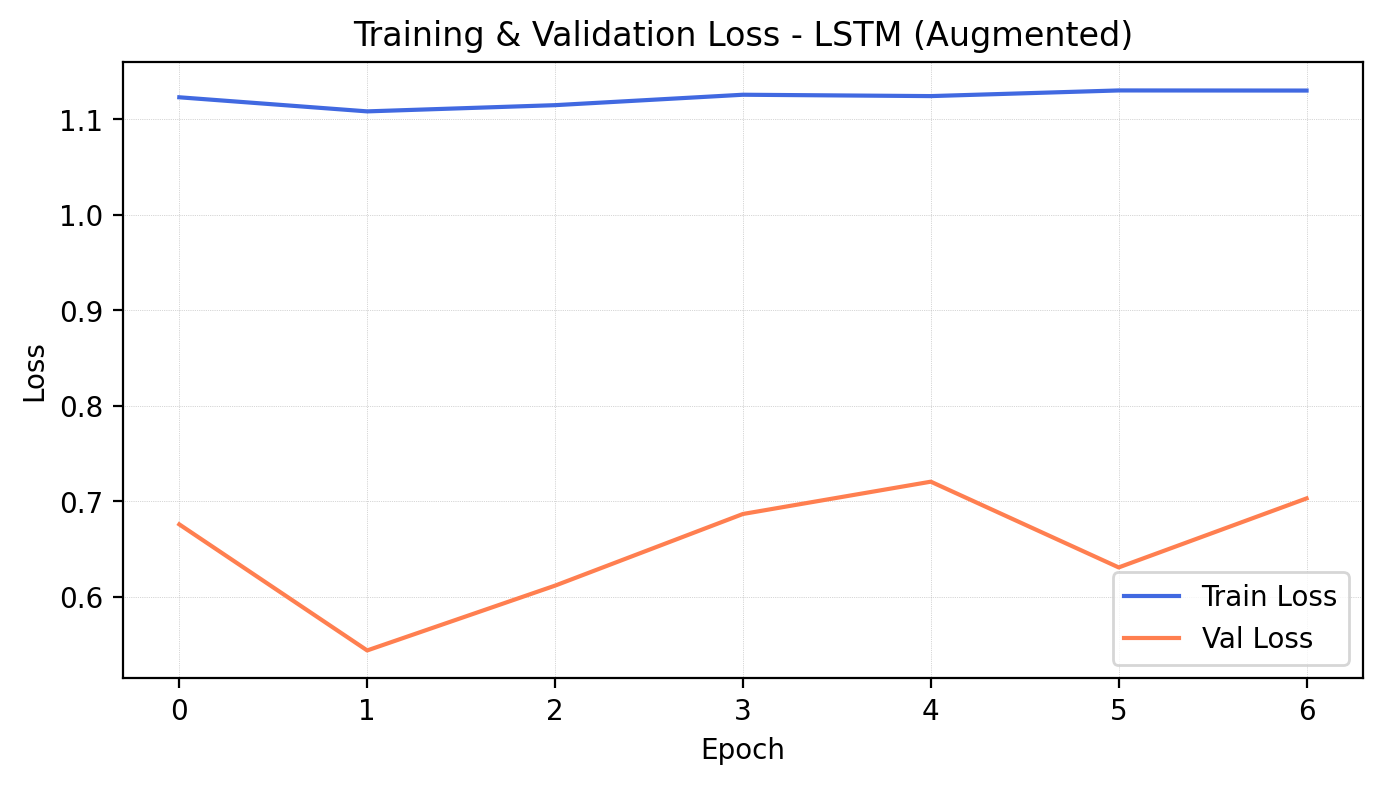


Best Threshold (from validation): 0.4518
Val Precision: 0.0135
Val Recall:    0.1429
Val F1:        0.0247

=== Confusion Matrix (Default Threshold = 0.5) ===
[[  0   5]
 [ 13 552]]
                precision    recall  f1-score   support

    Planet (2)       0.00      0.00      0.00         5
Non-planet (1)       0.99      0.98      0.98       565

      accuracy                           0.97       570
     macro avg       0.50      0.49      0.49       570
  weighted avg       0.98      0.97      0.98       570


=== Confusion Matrix (Tuned Threshold) ===
[[  1   4]
 [ 36 529]]
                precision    recall  f1-score   support

    Planet (2)       0.03      0.20      0.05         5
Non-planet (1)       0.99      0.94      0.96       565

      accuracy                           0.93       570
     macro avg       0.51      0.57      0.51       570
  weighted avg       0.98      0.93      0.96       570

ROC-AUC: 0.5979
PR-AUC:  0.0202


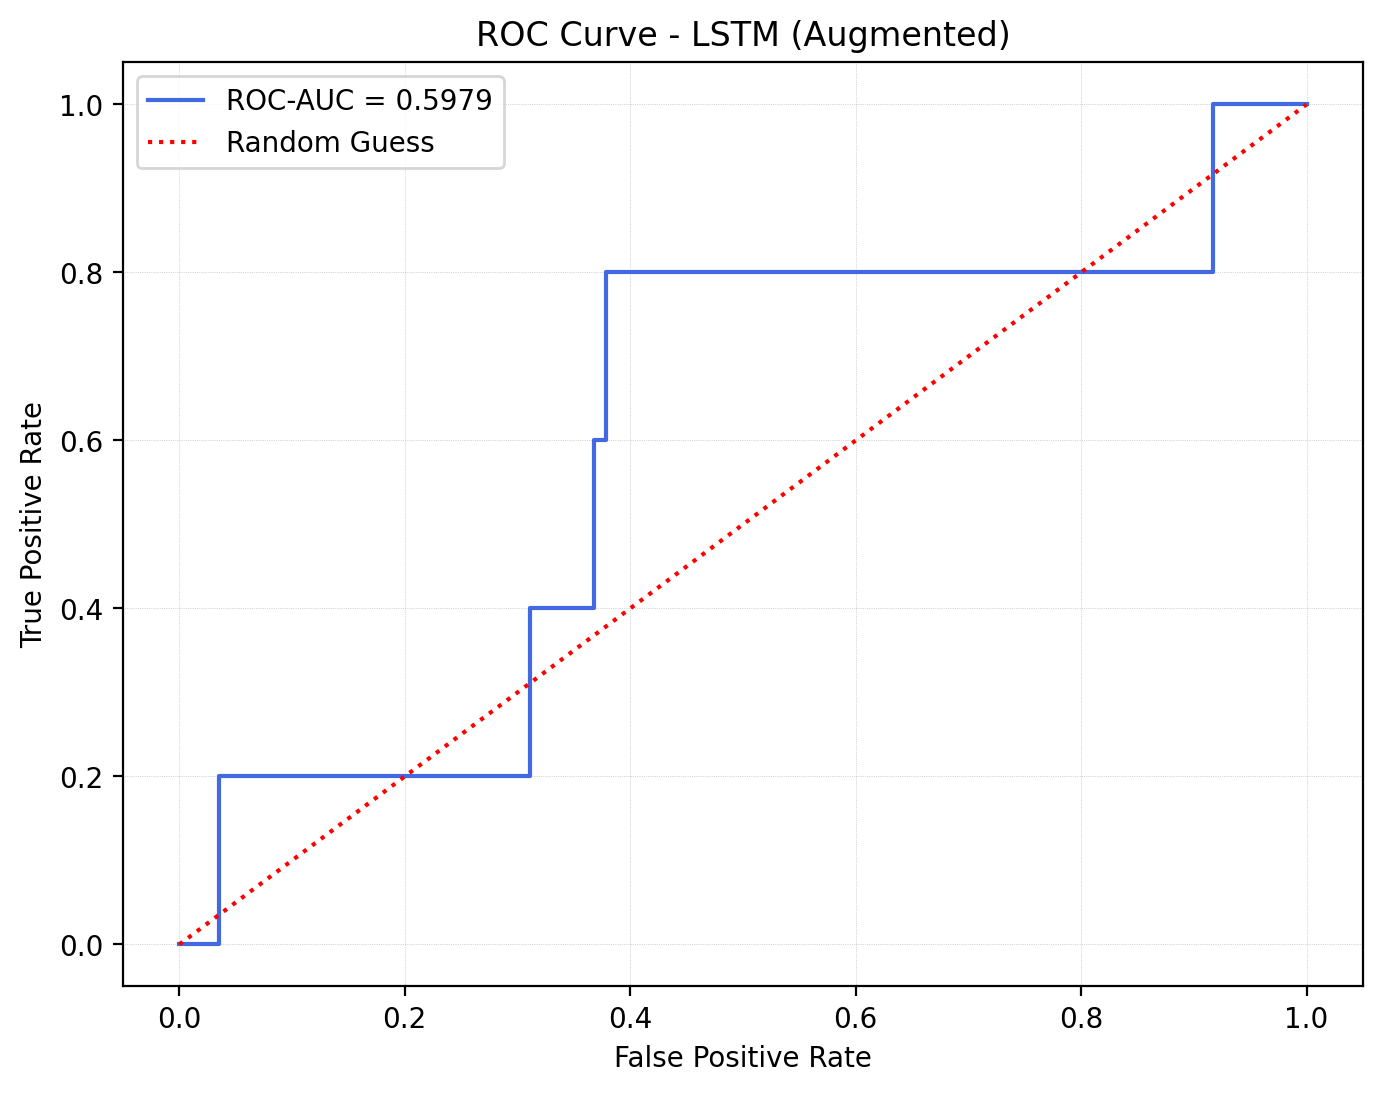

In [22]:
# ══════════════════════════════════════════════════════════════
# 9. LSTM
# ══════════════════════════════════════════════════════════════
 
print('\n' + '='*60)
print('LSTM')
print('='*60)
 
train_X_raw_dl = exoTrain.drop(columns=['LABEL']).values
train_y_raw_dl = (exoTrain['LABEL'] - 1).values
test_X_raw_dl  = exoTest.drop(columns=['LABEL']).values
test_y_raw_dl  = (exoTest['LABEL'] - 1).values
 
X_tr_l, X_val_l, y_tr_l, y_val_l, X_te_l, y_te_l = prepare_dl_data(
    train_X_raw_dl, train_y_raw_dl,
    test_X_raw_dl, test_y_raw_dl,
    use_augmentation=True, downsample=8   # 3197 → ~400
)
 
# reshape for LSTM: (samples, time_steps, 1)
X_tr_l  = X_tr_l.reshape(X_tr_l.shape[0], X_tr_l.shape[1], 1)
X_val_l = X_val_l.reshape(X_val_l.shape[0], X_val_l.shape[1], 1)
X_te_l  = X_te_l.reshape(X_te_l.shape[0], X_te_l.shape[1], 1)
 
lstm_train_loader = DataLoader(ExoDataset(X_tr_l, y_tr_l), batch_size=32, shuffle=True)
lstm_val_loader   = DataLoader(ExoDataset(X_val_l, y_val_l), batch_size=32, shuffle=False)
lstm_test_loader  = DataLoader(ExoDataset(X_te_l, y_te_l), batch_size=32, shuffle=False)
 
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)
 
lstm_model = LSTMClassifier().to(device)
lstm_model, lstm_train_losses, lstm_val_losses = train_dl_model(
    lstm_model, lstm_train_loader, lstm_val_loader
)
 
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=200)
ax.plot(lstm_train_losses, color='royalblue', label='Train Loss')
ax.plot(lstm_val_losses,   color='coral',     label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss - LSTM (Augmented)')
ax.legend(); ax.grid(axis='both', linestyle=':', linewidth=0.25)
plt.show()
 
lstm_auc, lstm_ap = evaluate_dl_model(
    lstm_model, lstm_val_loader, lstm_test_loader,
    y_val_l, y_te_l, title='LSTM (Augmented)'
)


1D CNN
After augmentation — train: 4969 samples, 930 positives
Validation kept clean: 1018 samples
Epoch 1/50 | Train Loss: 0.5309 | Val Loss: 0.3076
Epoch 2/50 | Train Loss: 0.1949 | Val Loss: 0.1323
Epoch 3/50 | Train Loss: 0.1070 | Val Loss: 0.1786
Epoch 4/50 | Train Loss: 0.0735 | Val Loss: 0.1902
Epoch 5/50 | Train Loss: 0.0393 | Val Loss: 0.1293
Epoch 6/50 | Train Loss: 0.0678 | Val Loss: 0.1672
Epoch 7/50 | Train Loss: 0.0571 | Val Loss: 0.1514
Epoch 8/50 | Train Loss: 0.0329 | Val Loss: 0.1514
Epoch 9/50 | Train Loss: 0.0211 | Val Loss: 0.1454
Epoch 10/50 | Train Loss: 0.0210 | Val Loss: 0.1478

Early stopping at epoch 10


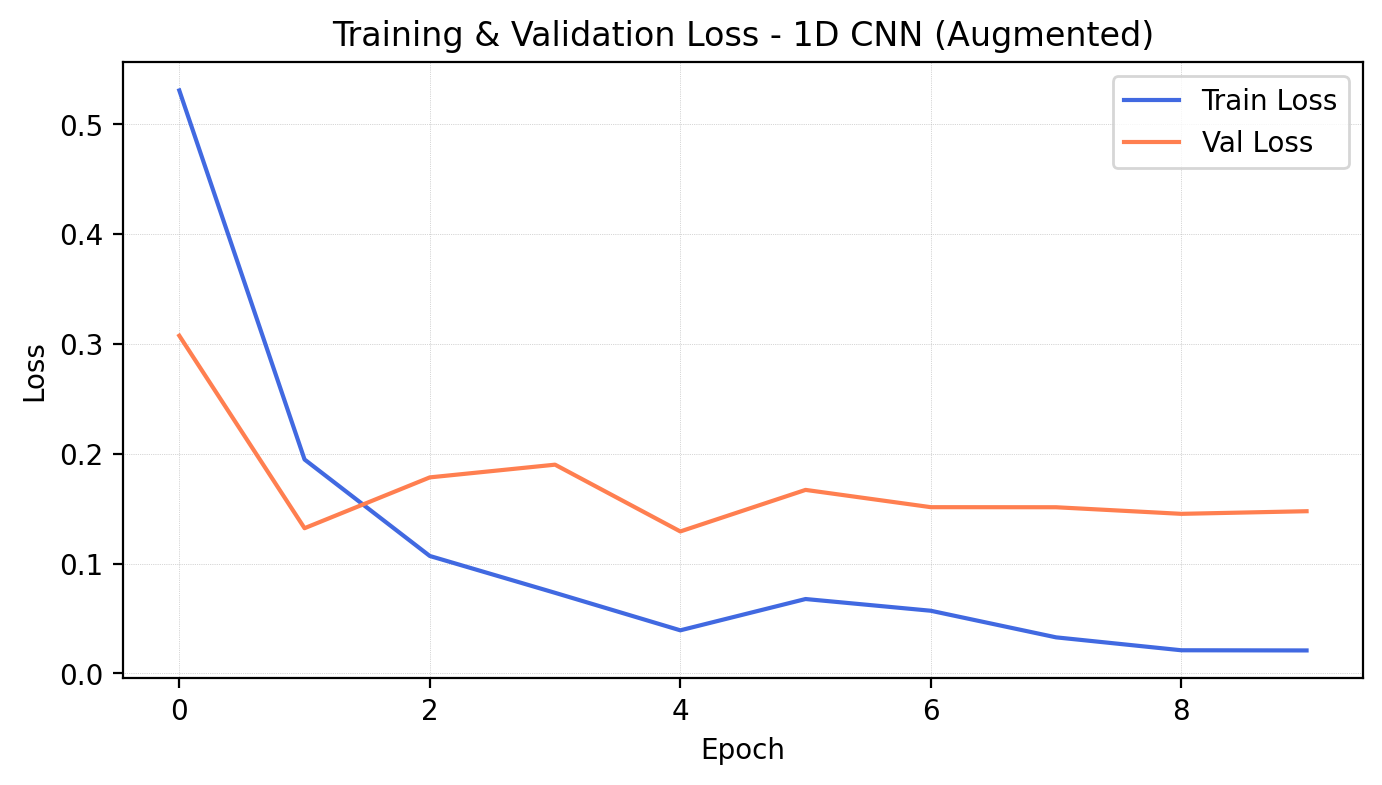


Best Threshold (from validation): 0.9972
Val Precision: 1.0000
Val Recall:    0.4286
Val F1:        0.6000

=== Confusion Matrix (Default Threshold = 0.5) ===
[[  5   0]
 [  2 563]]
                precision    recall  f1-score   support

    Planet (2)       0.71      1.00      0.83         5
Non-planet (1)       1.00      1.00      1.00       565

      accuracy                           1.00       570
     macro avg       0.86      1.00      0.92       570
  weighted avg       1.00      1.00      1.00       570


=== Confusion Matrix (Tuned Threshold) ===
[[  2   3]
 [  2 563]]
                precision    recall  f1-score   support

    Planet (2)       0.50      0.40      0.44         5
Non-planet (1)       0.99      1.00      1.00       565

      accuracy                           0.99       570
     macro avg       0.75      0.70      0.72       570
  weighted avg       0.99      0.99      0.99       570

ROC-AUC: 0.9968
PR-AUC:  0.5962


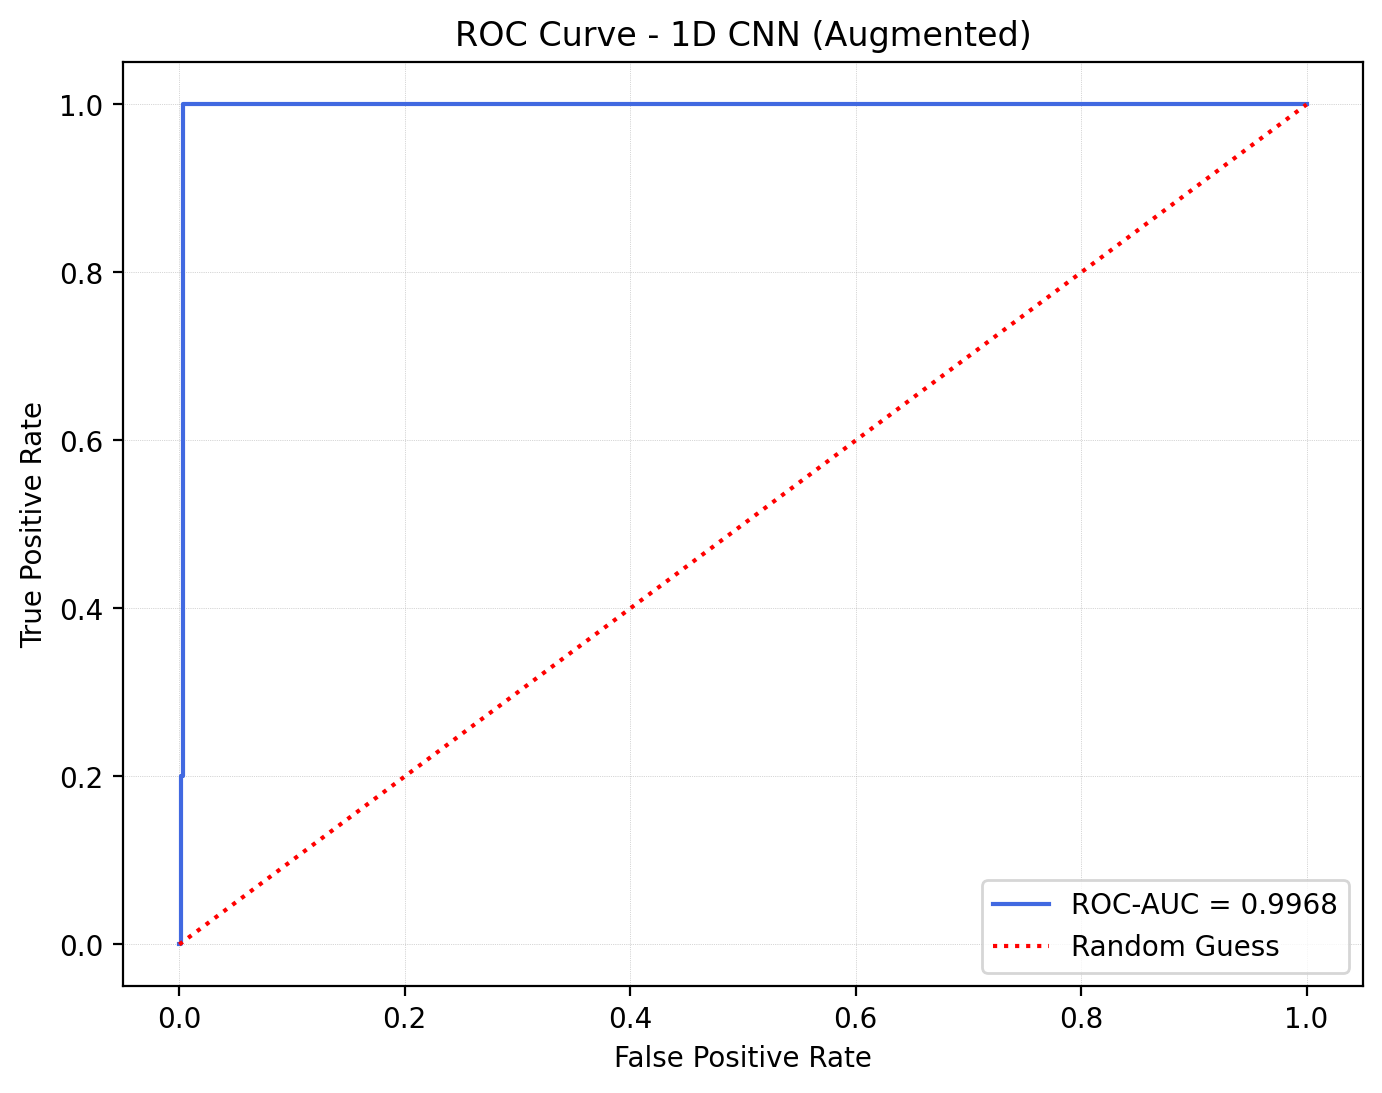

In [23]:
# ══════════════════════════════════════════════════════════════
# 10. 1D CNN
# ══════════════════════════════════════════════════════════════
 
print('\n' + '='*60)
print('1D CNN')
print('='*60)
 
X_tr_c, X_val_c, y_tr_c, y_val_c, X_te_c, y_te_c = prepare_dl_data(
    train_X_raw_dl, train_y_raw_dl,
    test_X_raw_dl, test_y_raw_dl,
    use_augmentation=True, downsample=None   # CNN handles full 3197
)
 
# reshape for CNN: (samples, 1, time_steps)
X_tr_c  = X_tr_c.reshape(X_tr_c.shape[0], 1, X_tr_c.shape[1])
X_val_c = X_val_c.reshape(X_val_c.shape[0], 1, X_val_c.shape[1])
X_te_c  = X_te_c.reshape(X_te_c.shape[0], 1, X_te_c.shape[1])
 
cnn_train_loader = DataLoader(ExoDataset(X_tr_c, y_tr_c), batch_size=32, shuffle=True)
cnn_val_loader   = DataLoader(ExoDataset(X_val_c, y_val_c), batch_size=32, shuffle=False)
cnn_test_loader  = DataLoader(ExoDataset(X_te_c, y_te_c), batch_size=32, shuffle=False)
 
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4),   # → 799
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),   # → 199
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),   # → 49
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 49, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
 
    def forward(self, x):
        return self.fc_block(self.conv_block(x)).squeeze(-1)
 
cnn_model = CNNClassifier().to(device)
cnn_model, cnn_train_losses, cnn_val_losses = train_dl_model(
    cnn_model, cnn_train_loader, cnn_val_loader
)
 
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=200)
ax.plot(cnn_train_losses, color='royalblue', label='Train Loss')
ax.plot(cnn_val_losses,   color='coral',     label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss - 1D CNN (Augmented)')
ax.legend(); ax.grid(axis='both', linestyle=':', linewidth=0.25)
plt.show()
 
cnn_auc, cnn_ap = evaluate_dl_model(
    cnn_model, cnn_val_loader, cnn_test_loader,
    y_val_c, y_te_c, title='1D CNN (Augmented)'
)


1D CNN (Engineered Features)
After augmentation — train: 4969 samples, 930 positives
Validation kept clean: 1018 samples
Extracting features on augmented train...
Extracting features on validation...
Train features: (4969, 1659)
Val features:   (1018, 1659)
Test features:  (570, 1659)
CNN input length (n_features): 1659
Epoch 1/50 | Train Loss: 0.2666 | Val Loss: 0.1521
Epoch 2/50 | Train Loss: 0.0555 | Val Loss: 0.1732
Epoch 3/50 | Train Loss: 0.0168 | Val Loss: 0.2181
Epoch 4/50 | Train Loss: 0.0185 | Val Loss: 0.1792
Epoch 5/50 | Train Loss: 0.0051 | Val Loss: 0.1905
Epoch 6/50 | Train Loss: 0.0049 | Val Loss: 0.1854

Early stopping at epoch 6


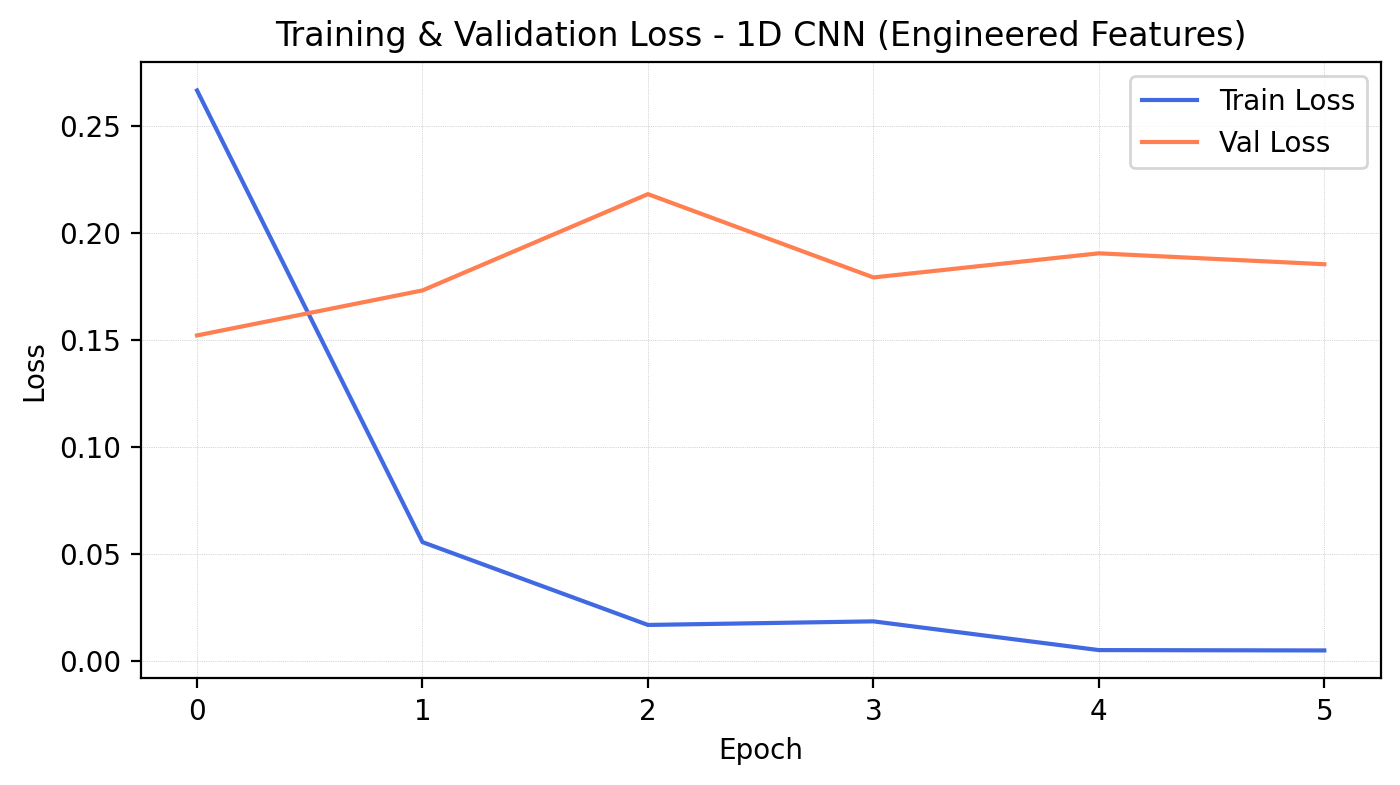


Best Threshold (from validation): 0.7305
Val Precision: 0.6000
Val Recall:    0.4286
Val F1:        0.5000

=== Confusion Matrix (Default Threshold = 0.5) ===
[[  5   0]
 [  7 558]]
                precision    recall  f1-score   support

    Planet (2)       0.42      1.00      0.59         5
Non-planet (1)       1.00      0.99      0.99       565

      accuracy                           0.99       570
     macro avg       0.71      0.99      0.79       570
  weighted avg       0.99      0.99      0.99       570


=== Confusion Matrix (Tuned Threshold) ===
[[  5   0]
 [  3 562]]
                precision    recall  f1-score   support

    Planet (2)       0.62      1.00      0.77         5
Non-planet (1)       1.00      0.99      1.00       565

      accuracy                           0.99       570
     macro avg       0.81      1.00      0.88       570
  weighted avg       1.00      0.99      1.00       570

ROC-AUC: 0.9986
PR-AUC:  0.8100


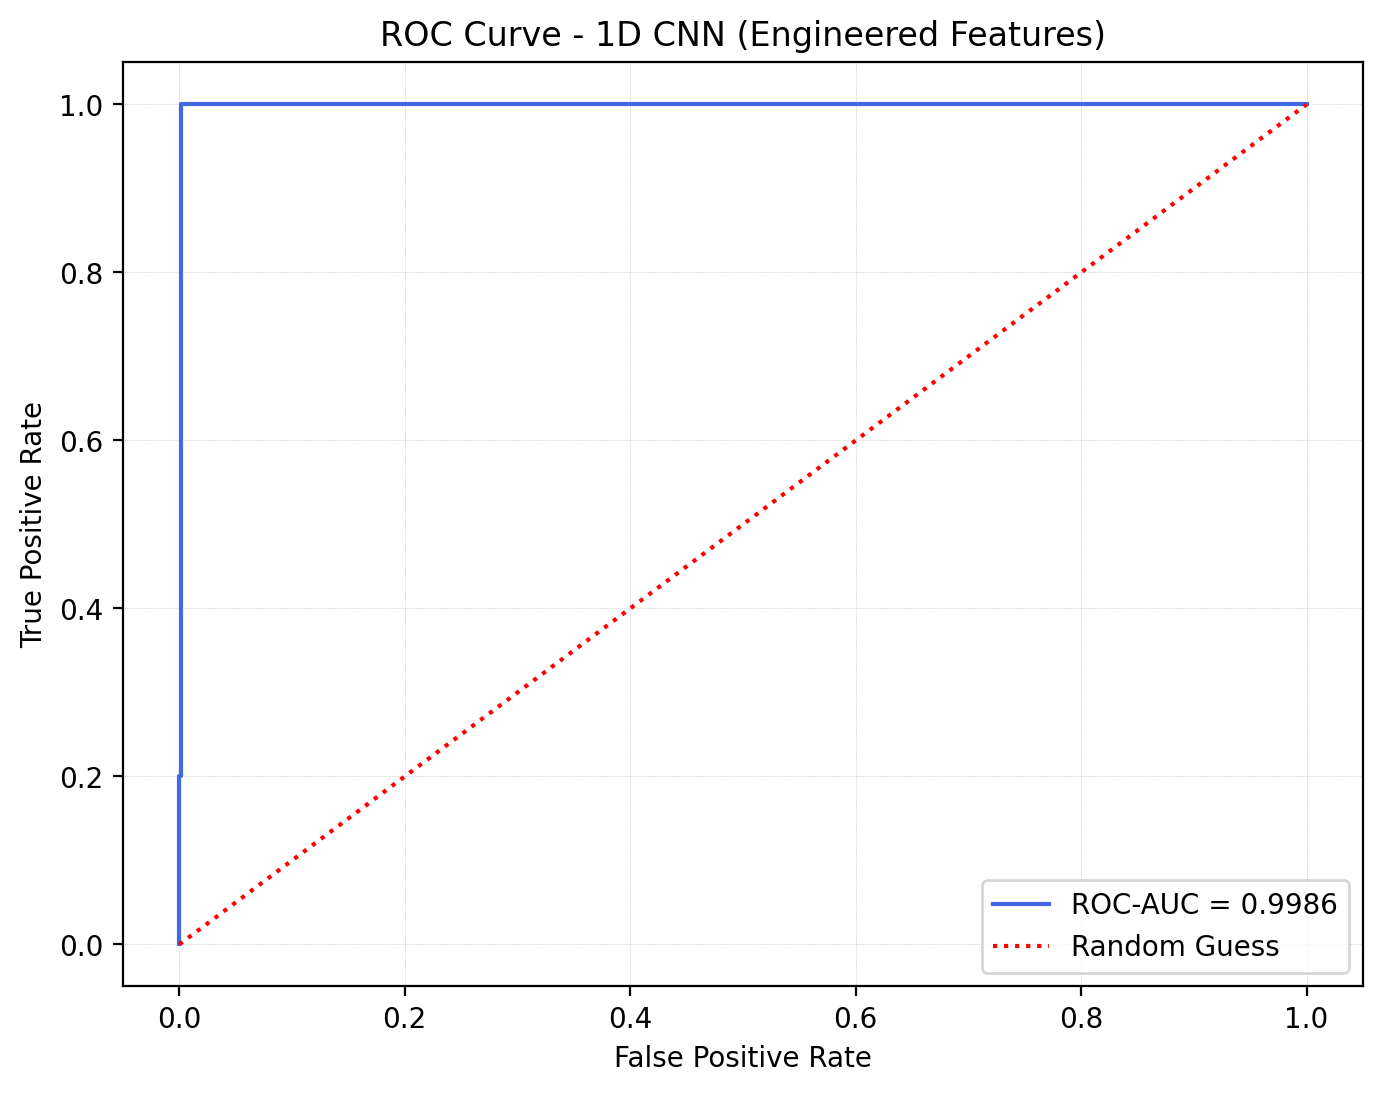

In [24]:
# ══════════════════════════════════════════════════════════════
# 11. 1D CNN (Engineered Features version)
# ══════════════════════════════════════════════════════════════
# Engineered features (FFT + hand-crafted) are reshaped into
# (samples, 1, n_features) and fed into the CNN.
# CNN learns local patterns across the feature dimension.
# Augmentation is applied AFTER split to avoid leakage.
# ──────────────────────────────────────────────────────────────
 
print('\n' + '='*60)
print('1D CNN (Engineered Features)')
print('='*60)
 
train_X_raw_eng = exoTrain.drop(columns=['LABEL']).values
train_y_raw_eng = (exoTrain['LABEL'] - 1).values
test_X_raw_eng  = exoTest.drop(columns=['LABEL']).values
y_te_e          = (exoTest['LABEL'] - 1).values
 
# ── Step 1: split raw signals FIRST ──────────────────────────
X_tr_raw_e, X_val_raw_e, y_tr_raw_e, y_val_e = train_test_split(
    train_X_raw_eng, train_y_raw_eng,
    test_size=0.2, stratify=train_y_raw_eng, random_state=42
)
 
# ── Step 2: augment only training split ──────────────────────
pos_mask_eng = y_tr_raw_e == 1
X_pos_eng    = X_tr_raw_e[pos_mask_eng]
 
aug_list_eng = []
for sig in X_pos_eng:
    aug_list_eng.append(augment_signal(sig, n_augments=30))
 
aug_pos_eng  = np.vstack(aug_list_eng)
X_tr_raw_aug_e = np.vstack([X_tr_raw_e, aug_pos_eng])
y_tr_e         = np.concatenate([y_tr_raw_e, np.ones(len(aug_pos_eng))])
 
print(f'After augmentation — train: {len(X_tr_raw_aug_e)} samples, '
      f'{int(y_tr_e.sum())} positives')
print(f'Validation kept clean: {len(X_val_raw_e)} samples')
 
# ── Step 3: extract features separately for each split ───────
print('Extracting features on augmented train...')
X_tr_eng = np.hstack([
    apply_fft(X_tr_raw_aug_e),
    extract_summary_stats(X_tr_raw_aug_e),
    dip_detection_features(X_tr_raw_aug_e),
    autocorrelation_features(X_tr_raw_aug_e),
    rolling_window_features(X_tr_raw_aug_e),
    derivative_features(X_tr_raw_aug_e),
])
 
print('Extracting features on validation...')
X_val_eng = np.hstack([
    apply_fft(X_val_raw_e),
    extract_summary_stats(X_val_raw_e),
    dip_detection_features(X_val_raw_e),
    autocorrelation_features(X_val_raw_e),
    rolling_window_features(X_val_raw_e),
    derivative_features(X_val_raw_e),
])
 
# test: use already-extracted features
X_test_eng = np.hstack([
    X_te_fft, X_te_stats, X_te_dips, X_te_ac, X_te_roll, X_te_deriv
])
 
print(f'Train features: {X_tr_eng.shape}')
print(f'Val features:   {X_val_eng.shape}')
print(f'Test features:  {X_test_eng.shape}')
 
# ── Step 4: scale using train only ───────────────────────────
scaler_eng         = StandardScaler()
X_tr_eng_scaled    = scaler_eng.fit_transform(X_tr_eng)
X_val_eng_scaled   = scaler_eng.transform(X_val_eng)
X_test_eng_scaled  = scaler_eng.transform(X_test_eng)
 
# ── Step 5: reshape to (samples, 1, n_features) for CNN ──────
n_feat  = X_tr_eng_scaled.shape[1]
X_tr_e  = X_tr_eng_scaled.reshape(X_tr_eng_scaled.shape[0], 1, n_feat)
X_val_e = X_val_eng_scaled.reshape(X_val_eng_scaled.shape[0], 1, n_feat)
X_te_e  = X_test_eng_scaled.reshape(X_test_eng_scaled.shape[0], 1, n_feat)
 
cnn_eng_train_loader = DataLoader(
    ExoDataset(X_tr_e, y_tr_e), batch_size=32, shuffle=True
)
cnn_eng_val_loader   = DataLoader(
    ExoDataset(X_val_e, y_val_e), batch_size=32, shuffle=False
)
cnn_eng_test_loader  = DataLoader(
    ExoDataset(X_te_e, y_te_e), batch_size=32, shuffle=False
)
 
# ── CNN Model (same architecture, different input length) ─────
class CNNEngClassifier(nn.Module):
    def __init__(self, input_len):
        super().__init__()
        # After 3x MaxPool1d(4): input_len → /4 → /4 → /4
        final_len = input_len // 4 // 4 // 4
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * final_len, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
 
    def forward(self, x):
        return self.fc_block(self.conv_block(x)).squeeze(-1)
 
input_len    = X_tr_e.shape[2]  # shape is (samples, 1, n_features)
cnn_eng_model = CNNEngClassifier(input_len=input_len).to(device)
print(f'CNN input length (n_features): {input_len}')
 
cnn_eng_model, cnn_eng_train_losses, cnn_eng_val_losses = train_dl_model(
    cnn_eng_model, cnn_eng_train_loader, cnn_eng_val_loader
)
 
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=200)
ax.plot(cnn_eng_train_losses, color='royalblue', label='Train Loss')
ax.plot(cnn_eng_val_losses,   color='coral',     label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss - 1D CNN (Engineered Features)')
ax.legend(); ax.grid(axis='both', linestyle=':', linewidth=0.25)
plt.show()
 
cnn_eng_auc, cnn_eng_ap = evaluate_dl_model(
    cnn_eng_model, cnn_eng_val_loader, cnn_eng_test_loader,
    y_val_e, y_te_e, title='1D CNN (Engineered Features)'
)


MODEL COMPARISON
                Model  ROC-AUC   PR-AUC
1D CNN (Eng Features) 0.998584 0.810000
         1D CNN (Raw) 0.996814 0.596190
              XGBoost 0.995752 0.858824
        Random Forest 0.995044 0.622222
  Logistic Regression 0.930973 0.522285
                 LSTM 0.597876 0.020196


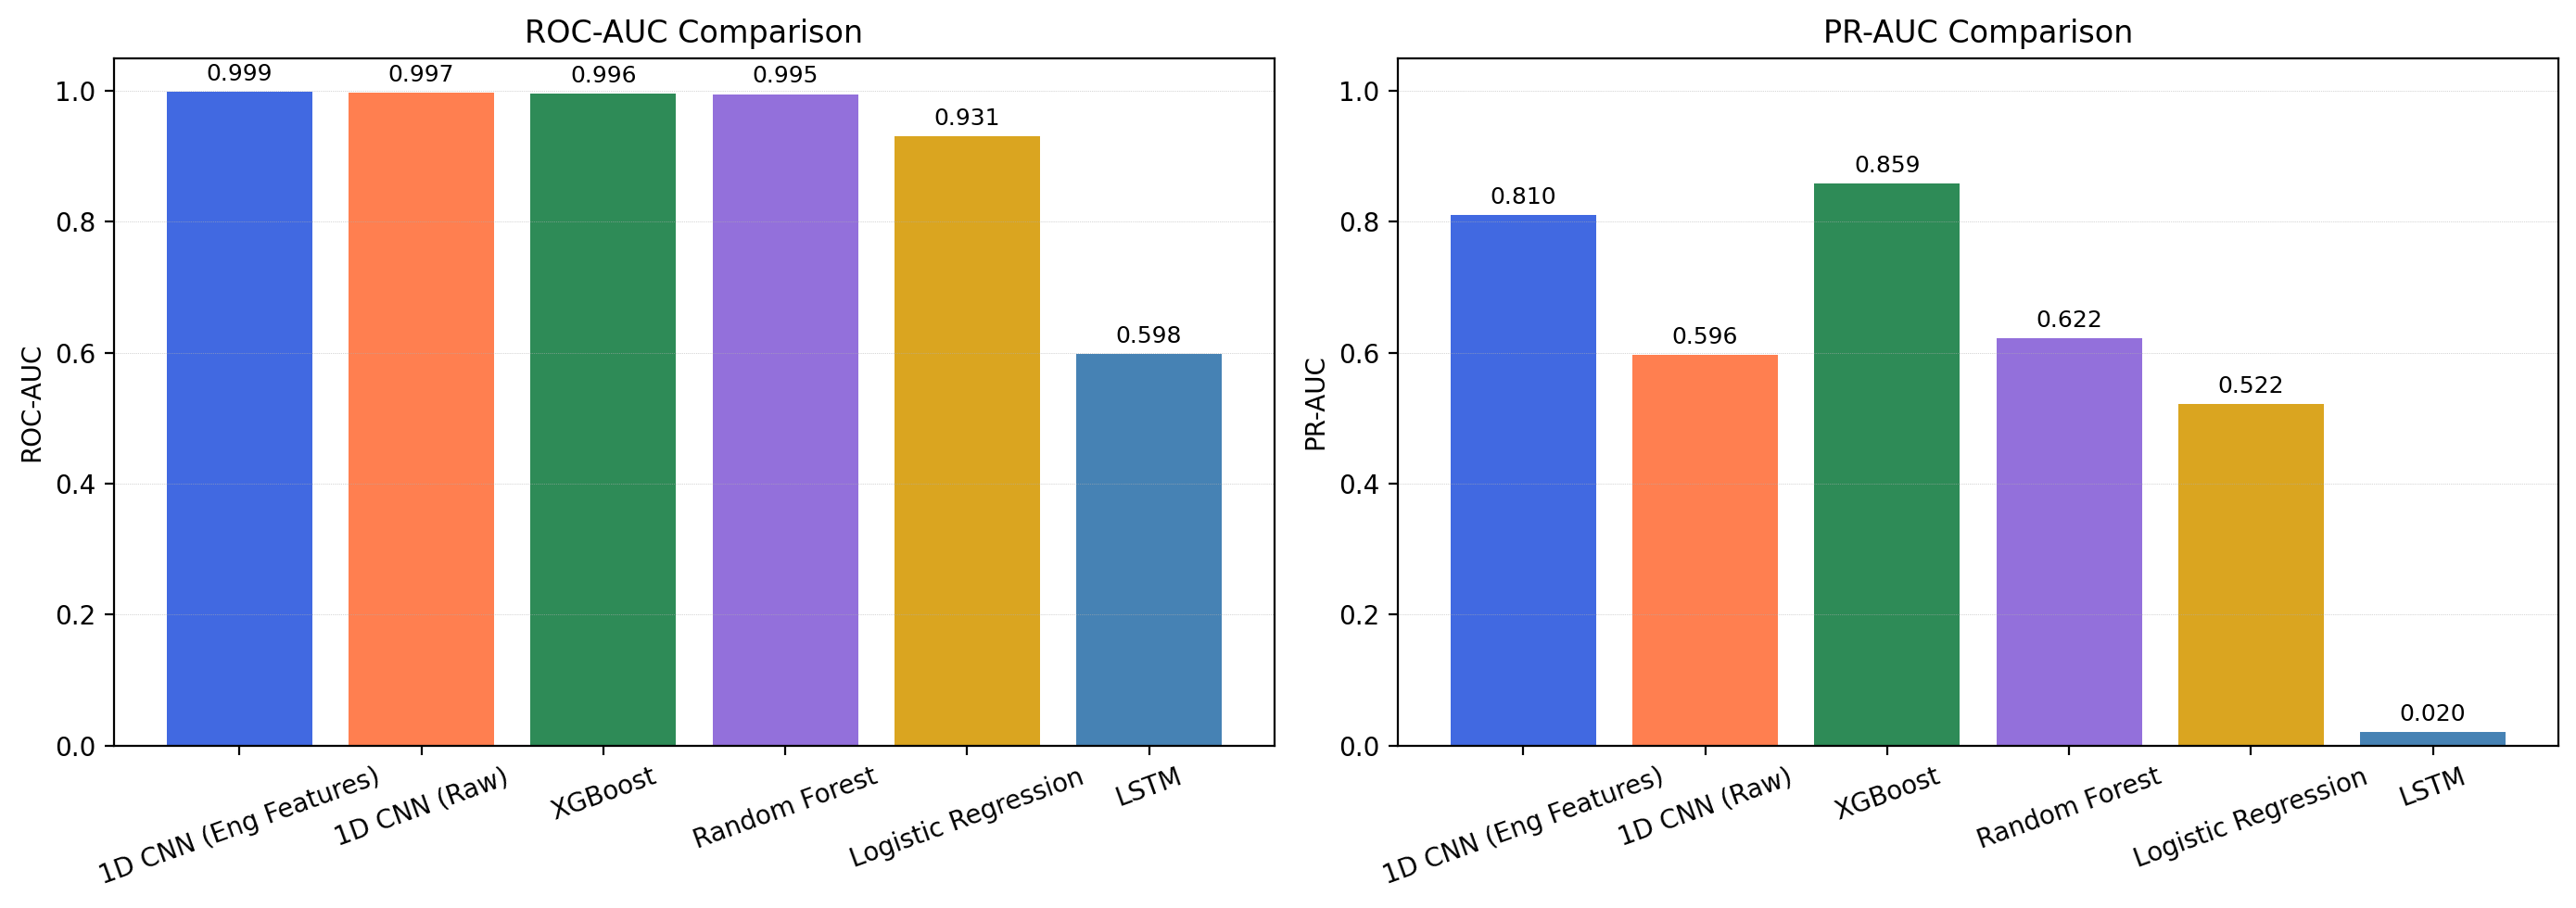

In [25]:
# ══════════════════════════════════════════════════════════════
# 12. MODEL COMPARISON
# ══════════════════════════════════════════════════════════════
 
print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)
 
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost',
              'LSTM', '1D CNN (Raw)', '1D CNN (Eng Features)'],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc, lstm_auc, cnn_auc, cnn_eng_auc],
    'PR-AUC':  [lr_ap,  rf_ap,  xgb_ap,  lstm_ap,  cnn_ap,  cnn_eng_ap],
})
results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)
colors = ['royalblue', 'coral', 'seagreen', 'mediumpurple', 'goldenrod', 'steelblue']
 
for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    bars = ax.bar(results['Model'], results[metric], color=colors)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle=':', linewidth=0.25)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.show()